# 💱 完整貨幣預測流程 - HuggingFace Transformer PatchTST

這個 notebook 實現了完整的貨幣預測流程：
1. 📊 資料收集 - 使用現有的下載流程
2. 🔄 資料處理 - 清理和特徵工程
3. ✂️ 資料分割 - train/validation/test
4. 🤖 模型訓練 - HuggingFace PatchTST Transformer
5. 📈 預測未來 - 預測一週後的匯率
6. 📊 視覺化 - 繪製預測結果圖表

## 📋 環境設置和導入

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 添加項目路徑
project_root = Path().absolute()
sys.path.append(str(project_root / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import logging

# 設置 logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


print("✅ 環境設置完成")
print(f"📁 項目路徑: {project_root}")
print(f"🕐 當前時間: {datetime.now()}")



✅ 環境設置完成
📁 項目路徑: d:\learn_python\currency_predict_attempt
🕐 當前時間: 2025-10-07 10:01:20.215624


In [2]:
# 🎯 完整的全域中文字型設定
import matplotlib as mpl
from matplotlib.font_manager import FontProperties, fontManager

# 設定中文字型路徑
chinese_font_path = "D:/tools/iansui/Iansui-Regular.ttf"

# 檢查字型檔案是否存在
import os
if os.path.exists(chinese_font_path):
    print(f"✅ 找到字型檔案: {chinese_font_path}")
    
    # 創建字型屬性物件
    chinese_font = FontProperties(fname=chinese_font_path)
    font_name = chinese_font.get_name()
    
    # 方法1: 註冊字型到系統
    fontManager.addfont(chinese_font_path)
    
    # 方法2: 設定字型家族的優先順序 (關鍵!)
    mpl.rcParams['font.family'] = ['sans-serif']
    mpl.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans', 'Arial Unicode MS', 'SimHei', 'Microsoft YaHei']
    
    # 方法3: 直接設定預設字型
    plt.rcParams['font.family'] = font_name
    
    # 解決負號顯示問題
    mpl.rcParams['axes.unicode_minus'] = False
    
    print(f"✅ 已設定中文字型: {font_name}")
    print("✅ 字型設定完成，所有圖表將自動使用中文字型")
    
else:
    print(f"❌ 找不到字型檔案: {chinese_font_path}")
    print("請檢查字型檔案路徑是否正確")


# 設定圖表樣式
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

plt.rcParams['font.family'] = chinese_font.get_name()
plt.rcParams['axes.unicode_minus'] = False

print("\n所有套件匯入成功！")

✅ 找到字型檔案: D:/tools/iansui/Iansui-Regular.ttf
✅ 已設定中文字型: Iansui
✅ 字型設定完成，所有圖表將自動使用中文字型

所有套件匯入成功！


✅ 中文字型測試通過


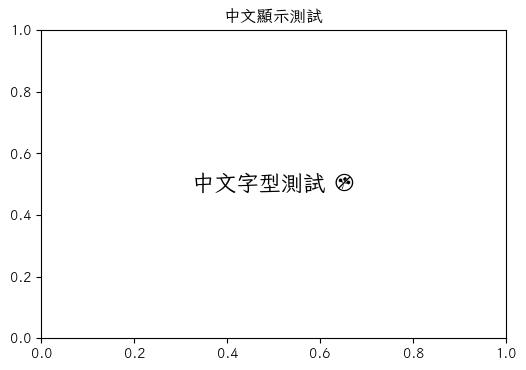

In [3]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.text(0.5, 0.5, '中文字型測試 💱', fontsize=16, ha='center', va='center')
ax.set_title('中文顯示測試')
# plt.close(fig)  # 關閉測試圖表
print("✅ 中文字型測試通過")

## 📊 步驟 1: 資料收集

使用現有的資料收集器下載最新的匯率資料

In [4]:
from currency_predictor.data_collector import CurrencyDataCollector
from currency_predictor.data.collectors import YahooFinanceCollector
from currency_predictor.utils import setup_logging

# 設置 logging
setup_logging()

# 初始化資料收集器
collector = CurrencyDataCollector()
yahoo_collector = YahooFinanceCollector()

print("✅ 資料收集器初始化完成")

2025-10-07 10:01:34,648 - currency_predictor.utils - INFO - Logging configured at INFO level
2025-10-07 10:01:34,649 - currency_predictor.data.collectors - INFO - Yahoo Finance 收集器已初始化
2025-10-07 10:01:34,649 - currency_predictor.data.collectors - INFO - Yahoo Finance 收集器已初始化


✅ 資料收集器初始化完成


In [5]:
# 定義要收集的貨幣對和時間範圍
currency_pairs = ['USDTWD=X']  # 美元/台幣
period = '2y'  # 最近2年的資料

# 下載資料
print("📥 開始下載匯率資料...")

raw_data = {}
for pair in currency_pairs:
    try:
        print(f"  📈 下載 {pair}...")
        data = yahoo_collector.get_currency_data(
            symbol=pair,
            period=period,
            interval='1d'
        )
        if data is not None and not data.empty:
            raw_data[pair] = data
            print(f"    ✅ {pair}: {len(data)} 筆資料 ({data.index[0]} ~ {data.index[-1]})")
        else:
            print(f"    ❌ {pair}: 無法獲取資料")
    except Exception as e:
        print(f"    ❌ {pair}: 錯誤 - {e}")

if not raw_data:
    print("\n⚠️  未能獲取新資料，嘗試讀取現有資料...")
    # 嘗試讀取現有的 CSV 檔案
    data_files = list(Path('data/raw').glob('USD*.csv'))
    if data_files:
        latest_file = max(data_files, key=lambda x: x.stat().st_mtime)
        print(f"📁 讀取檔案: {latest_file}")
        df = pd.read_csv(latest_file, index_col=0, parse_dates=True)
        raw_data['USDTWD=X'] = df
        print(f"✅ 成功讀取 {len(df)} 筆資料")
    else:
        print("❌ 沒有可用的資料檔案")
        
print(f"\n📊 總共獲得 {len(raw_data)} 個貨幣對的資料")

2025-10-07 10:01:34,656 - currency_predictor.data.collectors - INFO - 正在取得 USDTWD=X 的資料，期間: 2y


📥 開始下載匯率資料...
  📈 下載 USDTWD=X...


2025-10-07 10:01:36,905 - currency_predictor.data.collectors - INFO - 成功取得 USDTWD=X 的 519 筆資料


    ✅ USDTWD=X: 519 筆資料 (2023-10-09 00:00:00+01:00 ~ 2025-10-07 00:00:00+01:00)

📊 總共獲得 1 個貨幣對的資料


In [6]:
# 這邊下載完應該可以先畫個圖
raw_data

{'USDTWD=X':                                 Open       High        Low      Close  Volume  \
 Date                                                                            
 2023-10-09 00:00:00+01:00  32.118000  32.214001  32.118000  32.118000       0   
 2023-10-10 00:00:00+01:00  32.137299  32.175999  32.036800  32.137299       0   
 2023-10-11 00:00:00+01:00  32.016499  32.146999  32.004299  32.016499       0   
 2023-10-12 00:00:00+01:00  32.059200  32.213001  31.993999  32.059200       0   
 2023-10-13 00:00:00+01:00  32.169800  32.236801  32.162998  32.169800       0   
 ...                              ...        ...        ...        ...     ...   
 2025-10-01 00:00:00+01:00  30.442101  30.521000  30.368000  30.442101       0   
 2025-10-02 00:00:00+01:00  30.447001  30.488001  30.370800  30.447001       0   
 2025-10-03 00:00:00+01:00  30.463800  30.463800  30.333799  30.463800       0   
 2025-10-06 00:00:00+01:00  30.420000  30.580999  30.410000  30.420000       0   
 202

📊 開始進行資料視覺化分析...
🎯 分析貨幣對: USDTWD=X
📈 資料範圍: 2023-10-09 00:00:00+01:00 ~ 2025-10-07 00:00:00+01:00
📊 資料筆數: 519


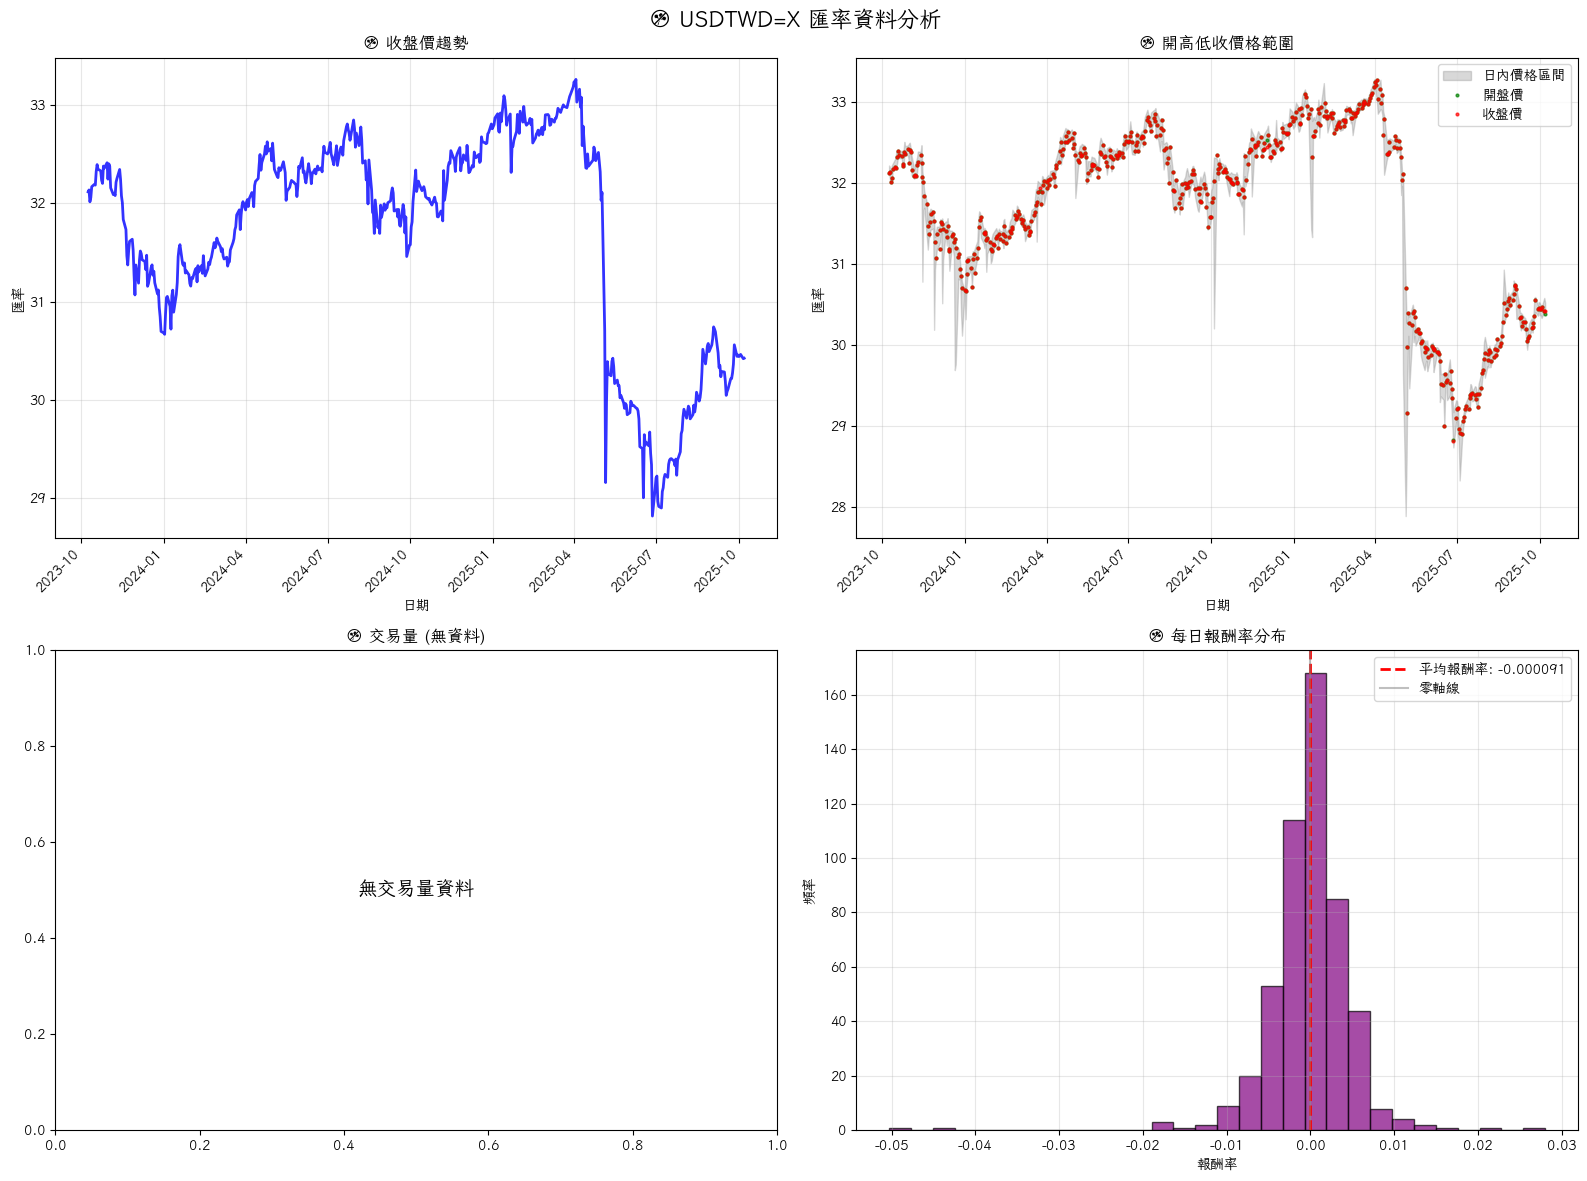


📋 USDTWD=X 基本統計分析:
💰 價格統計:
  期間最高價: 33.2760
  期間最低價: 27.8910
  期間平均價: 31.6835
  價格標準差: 1.0734

📊 報酬率統計:
  平均日報酬率: -0.000091 (-0.0091%)
  報酬率標準差: 0.005267 (0.5267%)
  最大單日漲幅: 0.028038 (2.80%)
  最大單日跌幅: -0.050296 (-5.03%)

📈 年化統計 (基於252交易日):
  年化報酬率: -0.0228 (-2.28%)
  年化波動率: 0.0836 (8.4%)
  夏普比率: -0.273

📅 期間表現:
  起始價格: 32.1180
  結束價格: 30.4250
  絕對變化: -1.6930
  相對變化: -5.27%

✅ USDTWD=X 資料分析完成！


In [7]:
# 🎨 資料收集完成後的視覺化分析
print("📊 開始進行資料視覺化分析...")

if raw_data:
    # 選擇主要貨幣對進行視覺化
    main_pair = list(raw_data.keys())[0]
    currency_data = raw_data[main_pair]
    
    print(f"🎯 分析貨幣對: {main_pair}")
    print(f"📈 資料範圍: {currency_data.index[0]} ~ {currency_data.index[-1]}")
    print(f"📊 資料筆數: {len(currency_data)}")
    
    # 建立多個子圖進行綜合分析
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'💱 {main_pair} 匯率資料分析', fontsize=16, fontweight='bold')
    
    # 1. 收盤價趨勢圖
    axes[0, 0].plot(currency_data.index, currency_data['Close'], 
                   linewidth=2, color='blue', alpha=0.8)
    axes[0, 0].set_title('📈 收盤價趨勢')
    axes[0, 0].set_xlabel('日期')
    axes[0, 0].set_ylabel('匯率')
    axes[0, 0].grid(True, alpha=0.3)
    plt.setp(axes[0, 0].get_xticklabels(), rotation=45, ha='right')
    
    # 2. OHLC 價格範圍圖
    axes[0, 1].fill_between(currency_data.index, 
                           currency_data['Low'], currency_data['High'],
                           alpha=0.3, color='gray', label='日內價格區間')
    axes[0, 1].plot(currency_data.index, currency_data['Open'], 
                   'o', markersize=2, color='green', label='開盤價', alpha=0.7)
    axes[0, 1].plot(currency_data.index, currency_data['Close'], 
                   'o', markersize=2, color='red', label='收盤價', alpha=0.7)
    axes[0, 1].set_title('📊 開高低收價格範圍')
    axes[0, 1].set_xlabel('日期')
    axes[0, 1].set_ylabel('匯率')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    plt.setp(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
    
    # 3. 交易量分析
    if 'Volume' in currency_data.columns and currency_data['Volume'].sum() > 0:
        # 過濾掉異常的零值
        volume_data = currency_data['Volume'][currency_data['Volume'] > 0]
        if len(volume_data) > 0:
            axes[1, 0].bar(volume_data.index, volume_data, 
                          alpha=0.7, color='orange', width=1)
            axes[1, 0].set_title('📊 交易量分布')
            axes[1, 0].set_xlabel('日期')
            axes[1, 0].set_ylabel('交易量')
            plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
            
            # 計算平均交易量
            avg_volume = volume_data.mean()
            axes[1, 0].axhline(y=avg_volume, color='red', linestyle='--', 
                              linewidth=2, alpha=0.8, label=f'平均交易量: {avg_volume:.0f}')
            axes[1, 0].legend()
        else:
            axes[1, 0].text(0.5, 0.5, '交易量資料為空', 
                           horizontalalignment='center', verticalalignment='center',
                           transform=axes[1, 0].transAxes, fontsize=14)
            axes[1, 0].set_title('📊 交易量 (無有效資料)')
    else:
        axes[1, 0].text(0.5, 0.5, '無交易量資料', 
                       horizontalalignment='center', verticalalignment='center',
                       transform=axes[1, 0].transAxes, fontsize=14)
        axes[1, 0].set_title('📊 交易量 (無資料)')
    
    # 4. 每日報酬率分布
    returns = currency_data['Close'].pct_change().dropna()
    if len(returns) > 0:
        axes[1, 1].hist(returns, bins=30, alpha=0.7, color='purple', edgecolor='black')
        axes[1, 1].axvline(returns.mean(), color='red', linestyle='--', 
                          linewidth=2, label=f'平均報酬率: {returns.mean():.6f}')
        axes[1, 1].axvline(0, color='gray', linestyle='-', alpha=0.5, label='零軸線')
        axes[1, 1].set_title('📊 每日報酬率分布')
        axes[1, 1].set_xlabel('報酬率')
        axes[1, 1].set_ylabel('頻率')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, '無法計算報酬率', 
                       horizontalalignment='center', verticalalignment='center',
                       transform=axes[1, 1].transAxes, fontsize=14)
        axes[1, 1].set_title('📊 每日報酬率分布 (無資料)')
    
    plt.tight_layout()
    plt.show()
    
    # 📈 基本統計分析
    print(f"\n📋 {main_pair} 基本統計分析:")
    print("=" * 50)
    
    # 價格統計
    print(f"💰 價格統計:")
    print(f"  期間最高價: {currency_data['High'].max():.4f}")
    print(f"  期間最低價: {currency_data['Low'].min():.4f}")
    print(f"  期間平均價: {currency_data['Close'].mean():.4f}")
    print(f"  價格標準差: {currency_data['Close'].std():.4f}")
    
    # 報酬率統計
    if len(returns) > 0:
        print(f"\n📊 報酬率統計:")
        print(f"  平均日報酬率: {returns.mean():.6f} ({returns.mean()*100:.4f}%)")
        print(f"  報酬率標準差: {returns.std():.6f} ({returns.std()*100:.4f}%)")
        print(f"  最大單日漲幅: {returns.max():.6f} ({returns.max()*100:.2f}%)")
        print(f"  最大單日跌幅: {returns.min():.6f} ({returns.min()*100:.2f}%)")
        
        # 年化統計 (假設252個交易日)
        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * np.sqrt(252)
        print(f"\n📈 年化統計 (基於252交易日):")
        print(f"  年化報酬率: {annual_return:.4f} ({annual_return*100:.2f}%)")
        print(f"  年化波動率: {annual_volatility:.4f} ({annual_volatility*100:.1f}%)")
        
        if annual_volatility > 0:
            sharpe_ratio = annual_return / annual_volatility
            print(f"  夏普比率: {sharpe_ratio:.3f}")
    
    # 期間表現
    if len(currency_data) >= 2:
        price_change = currency_data['Close'].iloc[-1] - currency_data['Close'].iloc[0]
        price_change_pct = (currency_data['Close'].iloc[-1] / currency_data['Close'].iloc[0] - 1) * 100
        
        print(f"\n📅 期間表現:")
        print(f"  起始價格: {currency_data['Close'].iloc[0]:.4f}")
        print(f"  結束價格: {currency_data['Close'].iloc[-1]:.4f}")
        print(f"  絕對變化: {price_change:+.4f}")
        print(f"  相對變化: {price_change_pct:+.2f}%")
    
    print(f"\n✅ {main_pair} 資料分析完成！")
    
else:
    print("❌ 沒有資料可供視覺化")
    print("請確保上一個步驟成功下載了資料")

## 🔄 步驟 2: 資料處理

清理資料並創建用於訓練的特徵

In [8]:
from currency_predictor.data_processor import DataProcessor

# 選擇主要貨幣對進行分析
main_pair = 'USDTWD=X'
if main_pair not in raw_data:
    main_pair = list(raw_data.keys())[0]
    
df_raw = raw_data[main_pair].copy()
print(f"🎯 分析貨幣對: {main_pair}")
print(f"📊 原始資料: {len(df_raw)} 筆, 時間範圍: {df_raw.index[0]} ~ {df_raw.index[-1]}")

# 檢查資料品質
print(f"\n📋 資料品質檢查:")
print(f"  缺失值: {df_raw.isnull().sum().sum()}")
print(f"  重複值: {df_raw.index.duplicated().sum()}")
print(f"\n📈 價格統計:")
print(df_raw['Close'].describe())

🎯 分析貨幣對: USDTWD=X
📊 原始資料: 519 筆, 時間範圍: 2023-10-09 00:00:00+01:00 ~ 2025-10-07 00:00:00+01:00

📋 資料品質檢查:
  缺失值: 0
  重複值: 0

📈 價格統計:
count    519.000000
mean      31.683451
std        1.073439
min       28.819000
25%       31.158050
50%       32.039001
75%       32.472500
max       33.262501
Name: Close, dtype: float64


In [9]:
print("🔄 開始資料處理流程: raw_data => df_features...")

# 初始化資料處理器
processor = DataProcessor()

# 清理資料
print("🧹 清理資料...")
df_clean = processor.clean_data(df_raw)
print(f"  清理後資料: {len(df_clean)} 筆")

# 添加技術指標 (創建 df_features)
print("📊 計算技術指標...")
df_features = processor.create_technical_indicators(df_clean)
print(f"  特徵數量: {len(df_features.columns)}")

# 顯示特徵欄位
print(f"\n📋 可用特徵:")
for i, col in enumerate(df_features.columns):
    print(f"  {i+1:2d}. {col}")

print(f"\n✅ 資料處理完成！df_features 已建立")
print(f"📊 df_features 形狀: {df_features.shape}")
print(f"📅 時間範圍: {df_features.index[0]} ~ {df_features.index[-1]}")

# 設定目標預測天數
target_days = 7

2025-10-07 10:01:41,697 - currency_predictor.data_processor - INFO - Data cleaned: 519 records remaining
2025-10-07 10:01:41,704 - currency_predictor.data_processor - INFO - Technical indicators created: 28 total features
2025-10-07 10:01:41,704 - currency_predictor.data_processor - INFO - Technical indicators created: 28 total features


🔄 開始資料處理流程: raw_data => df_features...
🧹 清理資料...
  清理後資料: 519 筆
📊 計算技術指標...
  特徵數量: 28

📋 可用特徵:
   1. Open
   2. High
   3. Low
   4. Close
   5. Volume
   6. Dividends
   7. Stock Splits
   8. MA_5
   9. MA_10
  10. MA_20
  11. MA_50
  12. EMA_12
  13. EMA_26
  14. MACD
  15. MACD_Signal
  16. MACD_Histogram
  17. RSI
  18. BB_Middle
  19. BB_Upper
  20. BB_Lower
  21. BB_Width
  22. BB_Position
  23. Volatility
  24. Price_Change
  25. Price_Change_5
  26. Price_Change_10
  27. Volume_MA
  28. Volume_Ratio

✅ 資料處理完成！df_features 已建立
📊 df_features 形狀: (519, 28)
📅 時間範圍: 2023-10-09 00:00:00 ~ 2025-10-07 00:00:00


In [10]:
# 🔍 特徵選擇分析和優化
print("🔍 分析所有可用特徵...")
print(f"📊 總共有 {len(df_features.columns)} 個特徵:")
for i, col in enumerate(df_features.columns):
    print(f"  {i+1:2d}. {col}")

print(f"\n📈 基礎 OHLCV 特徵:")
ohlcv_features = ['Open', 'High', 'Low', 'Close', 'Volume']
available_ohlcv = [f for f in ohlcv_features if f in df_features.columns]
print(f"  可用: {available_ohlcv}")

print(f"\n📊 技術指標特徵:")
technical_features = [col for col in df_features.columns if col not in ohlcv_features]
print(f"  技術指標數量: {len(technical_features)}")
for f in technical_features[:10]:  # 只顯示前10個
    print(f"    - {f}")
if len(technical_features) > 10:
    print(f"    ... 還有 {len(technical_features) - 10} 個")

# 優化特徵選擇策略
print(f"\n💡 特徵選擇建議:")
print("  📍 核心特徵 (必選):")
print("    - Open, High, Low, Close (OHLC價格)")
print("    - Volume (交易量)")
print("  📊 統計特徵:")
print("    - Volatility (波動率/標準差)")
print("    - Price_Change (價格變化率)")
print("  📈 趨勢特徵:")
print("    - MA_20, MA_50 (移動平均)")
print("    - EMA_12, EMA_26 (指數移動平均)")
print("  🎯 動量特徵:")
print("    - RSI (相對強弱)")
print("    - MACD (趨勢動量)")

🔍 分析所有可用特徵...
📊 總共有 28 個特徵:
   1. Open
   2. High
   3. Low
   4. Close
   5. Volume
   6. Dividends
   7. Stock Splits
   8. MA_5
   9. MA_10
  10. MA_20
  11. MA_50
  12. EMA_12
  13. EMA_26
  14. MACD
  15. MACD_Signal
  16. MACD_Histogram
  17. RSI
  18. BB_Middle
  19. BB_Upper
  20. BB_Lower
  21. BB_Width
  22. BB_Position
  23. Volatility
  24. Price_Change
  25. Price_Change_5
  26. Price_Change_10
  27. Volume_MA
  28. Volume_Ratio

📈 基礎 OHLCV 特徵:
  可用: ['Open', 'High', 'Low', 'Close', 'Volume']

📊 技術指標特徵:
  技術指標數量: 23
    - Dividends
    - Stock Splits
    - MA_5
    - MA_10
    - MA_20
    - MA_50
    - EMA_12
    - EMA_26
    - MACD
    - MACD_Signal
    ... 還有 13 個

💡 特徵選擇建議:
  📍 核心特徵 (必選):
    - Open, High, Low, Close (OHLC價格)
    - Volume (交易量)
  📊 統計特徵:
    - Volatility (波動率/標準差)
    - Price_Change (價格變化率)
  📈 趨勢特徵:
    - MA_20, MA_50 (移動平均)
    - EMA_12, EMA_26 (指數移動平均)
  🎯 動量特徵:
    - RSI (相對強弱)
    - MACD (趨勢動量)


In [11]:
# 🎯 特徵選擇策略函數化
def select_features(df_features, strategy='basic'):
    """
    根據策略選擇特徵
    
    Parameters:
    -----------
    df_features : pandas.DataFrame
        包含所有特徵的資料框
    strategy : str, default='basic'
        特徵選擇策略，可選：'basic', 'enhanced', 'technical', 'comprehensive'
    
    Returns:
    --------
    list : 可用的特徵列表
    dict : 策略資訊
    """
    
    # 定義不同層次的特徵組合
    feature_strategies = {
        'basic': {
            'features': ['Open', 'High', 'Low', 'Close', 'Volume'],
            'description': '基礎 OHLCV 特徵'
        },
        'enhanced': {
            'features': ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change'],
            'description': '基礎 + 統計特徵 (波動率、價格變化)'
        },
        'technical': {
            'features': ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change', 
                        'MA_20', 'EMA_12', 'RSI', 'MACD'],
            'description': '基礎 + 統計 + 技術指標'
        },
        'comprehensive': {
            'features': ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change',
                        'MA_5', 'MA_20', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'BB_Width', 'BB_Position'],
            'description': '全面特徵組合'
        }
    }
    
    if strategy not in feature_strategies:
        raise ValueError(f"不支援的策略: {strategy}. 可選策略: {list(feature_strategies.keys())}")
    
    # 檢查哪些特徵實際可用
    print("📋 特徵策略分析:")
    for strategy_name, strategy_info in feature_strategies.items():
        available = [f for f in strategy_info['features'] if f in df_features.columns]
        missing = [f for f in strategy_info['features'] if f not in df_features.columns]
        
        status = "🎯" if strategy_name == strategy else "  "
        print(f"{status} {strategy_name.upper()} 策略:")
        print(f"     描述: {strategy_info['description']}")
        print(f"     可用特徵 ({len(available)}): {available}")
        if missing:
            print(f"     缺失特徵 ({len(missing)}): {missing}")
        print()
    
    # 獲取選中策略的特徵
    selected_strategy = feature_strategies[strategy]
    recommended_features = selected_strategy['features']
    available_features = [f for f in recommended_features if f in df_features.columns]
    
    print(f"✅ 選擇策略: {strategy.upper()}")
    print(f"   描述: {selected_strategy['description']}")
    
    # 如果某些基礎特徵不存在，使用替代方案
    if strategy in ['basic', 'enhanced'] and len(available_features) < len(recommended_features):
        print("   🔧 特徵修正:")
        
        # 檢查基礎 OHLC 特徵
        ohlc_missing = []
        for feature in ['Open', 'High', 'Low']:
            if feature not in df_features.columns:
                ohlc_missing.append(feature)
        
        if ohlc_missing:
            print(f"     ⚠️  缺失 OHLC 特徵: {ohlc_missing}")
            # 確保至少有 Close
            if 'Close' not in available_features and 'Close' in df_features.columns:
                available_features.append('Close')
        
        # 對於 enhanced 策略，檢查統計特徵
        if strategy == 'enhanced':
            if 'Volatility' not in df_features.columns:
                print("     ⚠️  缺失 Volatility，尋找替代...")
                # 尋找其他波動率指標
                volatility_alternatives = [col for col in df_features.columns 
                                         if 'volatility' in col.lower() or 'std' in col.lower()]
                if volatility_alternatives and volatility_alternatives[0] not in available_features:
                    available_features.append(volatility_alternatives[0])
                    print(f"     ✅ 使用替代: {volatility_alternatives[0]}")
            
            if 'Price_Change' not in df_features.columns:
                print("     ⚠️  缺失 Price_Change")
    
    # 確保至少有基本特徵
    if not available_features:
        available_features = ['Close', 'Volume'] if 'Volume' in df_features.columns else ['Close']
        print("   ⚠️  回退到最基本特徵組合")
    
    # 去除重複特徵
    available_features = list(dict.fromkeys(available_features))
    
    print(f"\n🎯 {strategy.upper()} 策略最終特徵 ({len(available_features)}):")
    for i, feature in enumerate(available_features):
        print(f"  {i+1}. {feature}")
    
    return available_features, selected_strategy

# 使用函數選擇特徵策略
print("🎯 開始特徵選擇...")
selected_features, strategy_info = select_features(df_features, strategy='basic')

# 更新全局變量
available_features = selected_features
print(f"\n✅ 特徵選擇完成！使用 {len(available_features)} 個特徵")

🎯 開始特徵選擇...
📋 特徵策略分析:
🎯 BASIC 策略:
     描述: 基礎 OHLCV 特徵
     可用特徵 (5): ['Open', 'High', 'Low', 'Close', 'Volume']

   ENHANCED 策略:
     描述: 基礎 + 統計特徵 (波動率、價格變化)
     可用特徵 (7): ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change']

   TECHNICAL 策略:
     描述: 基礎 + 統計 + 技術指標
     可用特徵 (11): ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change', 'MA_20', 'EMA_12', 'RSI', 'MACD']

   COMPREHENSIVE 策略:
     描述: 全面特徵組合
     可用特徵 (15): ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change', 'MA_5', 'MA_20', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'BB_Width', 'BB_Position']

✅ 選擇策略: BASIC
   描述: 基礎 OHLCV 特徵

🎯 BASIC 策略最終特徵 (5):
  1. Open
  2. High
  3. Low
  4. Close
  5. Volume

✅ 特徵選擇完成！使用 5 個特徵


In [12]:
# 🔄 準備時間序列資料 (使用已選擇的特徵)
print("⏰ 準備時間序列資料...")

# 使用之前選擇的特徵策略，而不是重新定義
print(f"📊 使用已選擇的特徵 ({len(available_features)}): {available_features}")

# 驗證特徵是否存在於 df_features 中
missing_features = [f for f in available_features if f not in df_features.columns]
if missing_features:
    print(f"⚠️  發現缺失特徵: {missing_features}")
    # 只保留存在的特徵
    available_features = [f for f in available_features if f in df_features.columns]
    print(f"✅ 調整後特徵: {available_features}")

# 創建目標變數 (未來7天的收盤價)
target_days = 7
df_features['target'] = df_features['Close'].shift(-target_days)

# 移除有缺失值的行
df_model = df_features[available_features + ['target']].dropna()

print(f"✅ 模型資料準備完成:")
print(f"  使用特徵: {available_features}")
print(f"  資料筆數: {len(df_model)}")
print(f"  時間範圍: {df_model.index[0]} ~ {df_model.index[-1]}")

# 顯示資料摘要
print(f"\n📊 特徵資料摘要:")
print(df_model[available_features].describe())

⏰ 準備時間序列資料...
📊 使用已選擇的特徵 (5): ['Open', 'High', 'Low', 'Close', 'Volume']
✅ 模型資料準備完成:
  使用特徵: ['Open', 'High', 'Low', 'Close', 'Volume']
  資料筆數: 512
  時間範圍: 2023-10-09 00:00:00 ~ 2025-09-26 00:00:00

📊 特徵資料摘要:
             Open        High         Low       Close  Volume
count  512.000000  512.000000  512.000000  512.000000   512.0
mean    31.700564   31.809491   31.574043   31.700412     0.0
std      1.070879    1.065264    1.121450    1.070833     0.0
min     28.834000   28.979000   27.891001   28.819000     0.0
25%     31.194500   31.353251   30.931700   31.194500     0.0
50%     32.055099   32.164999   31.979000   32.055099     0.0
75%     32.487051   32.578750   32.398925   32.478452     0.0
max     33.262501   33.276001   33.187801   33.262501     0.0


In [13]:
# 🎯 快速切換特徵策略演示
print("🔄 演示特徵策略快速切換...")

def quick_feature_selection(df_features, strategy='basic'):
    """
    快速特徵選擇並準備模型資料
    
    Parameters:
    -----------
    df_features : pandas.DataFrame
        包含所有特徵的資料框
    strategy : str, default='basic'
        策略選擇：'basic', 'enhanced', 'technical', 'comprehensive'
    
    Returns:
    --------
    tuple: (available_features, df_model, strategy_info)
    """
    
    print(f"🎯 切換到 {strategy.upper()} 策略...")
    
    # 選擇特徵
    available_features, strategy_info = select_features(df_features, strategy=strategy)
    
    # 準備模型資料
    target_days = 7
    df_features_copy = df_features.copy()
    df_features_copy['target'] = df_features_copy['Close'].shift(-target_days)
    df_model = df_features_copy[available_features + ['target']].dropna()
    
    print(f"\n✅ {strategy.upper()} 策略準備完成:")
    print(f"  特徵數量: {len(available_features)}")
    print(f"  資料筆數: {len(df_model)}")
    
    return available_features, df_model, strategy_info

# 演示不同策略的效果
print("\n" + "="*60)
print("📊 各策略比較:")
print("="*60)

strategies = ['basic', 'enhanced', 'technical']
strategy_results = {}

for strategy in strategies:
    print(f"\n🎯 測試 {strategy.upper()} 策略:")
    print("-" * 30)
    
    features, model_data, info = quick_feature_selection(df_features, strategy)
    strategy_results[strategy] = {
        'features': features,
        'feature_count': len(features),
        'data_points': len(model_data),
        'description': info['description']
    }
    
    print(f"特徵: {features}")

print(f"\n📋 策略比較摘要:")
print("-" * 60)
for strategy, result in strategy_results.items():
    print(f"{strategy.upper():12} | {result['feature_count']:2d} 特徵 | {result['data_points']:3d} 筆資料 | {result['description']}")

print(f"\n💡 使用建議:")
print(f"• BASIC: 適合快速測試和基線模型")
print(f"• ENHANCED: 平衡性能和複雜度")
print(f"• TECHNICAL: 適合詳細分析和進階預測")

# 回到原本選擇的 basic 策略
print(f"\n🔄 回到 BASIC 策略...")
available_features, df_model, _ = quick_feature_selection(df_features, 'basic')

🔄 演示特徵策略快速切換...

📊 各策略比較:

🎯 測試 BASIC 策略:
------------------------------
🎯 切換到 BASIC 策略...
📋 特徵策略分析:
🎯 BASIC 策略:
     描述: 基礎 OHLCV 特徵
     可用特徵 (5): ['Open', 'High', 'Low', 'Close', 'Volume']

   ENHANCED 策略:
     描述: 基礎 + 統計特徵 (波動率、價格變化)
     可用特徵 (7): ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change']

   TECHNICAL 策略:
     描述: 基礎 + 統計 + 技術指標
     可用特徵 (11): ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change', 'MA_20', 'EMA_12', 'RSI', 'MACD']

   COMPREHENSIVE 策略:
     描述: 全面特徵組合
     可用特徵 (15): ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Price_Change', 'MA_5', 'MA_20', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'BB_Width', 'BB_Position']

✅ 選擇策略: BASIC
   描述: 基礎 OHLCV 特徵

🎯 BASIC 策略最終特徵 (5):
  1. Open
  2. High
  3. Low
  4. Close
  5. Volume

✅ BASIC 策略準備完成:
  特徵數量: 5
  資料筆數: 512
特徵: ['Open', 'High', 'Low', 'Close', 'Volume']

🎯 測試 ENHANCED 策略:
------------------------------
🎯 切換到 ENHANCED 策略...
📋 特徵策略分析:
   BASIC 策略:
     描述: 基礎 OHL

📊 開始 df_model 視覺化分析...
🎯 使用特徵: ['Open', 'High', 'Low', 'Close', 'Volume']
📈 資料概況: 512 筆資料，6 個欄位


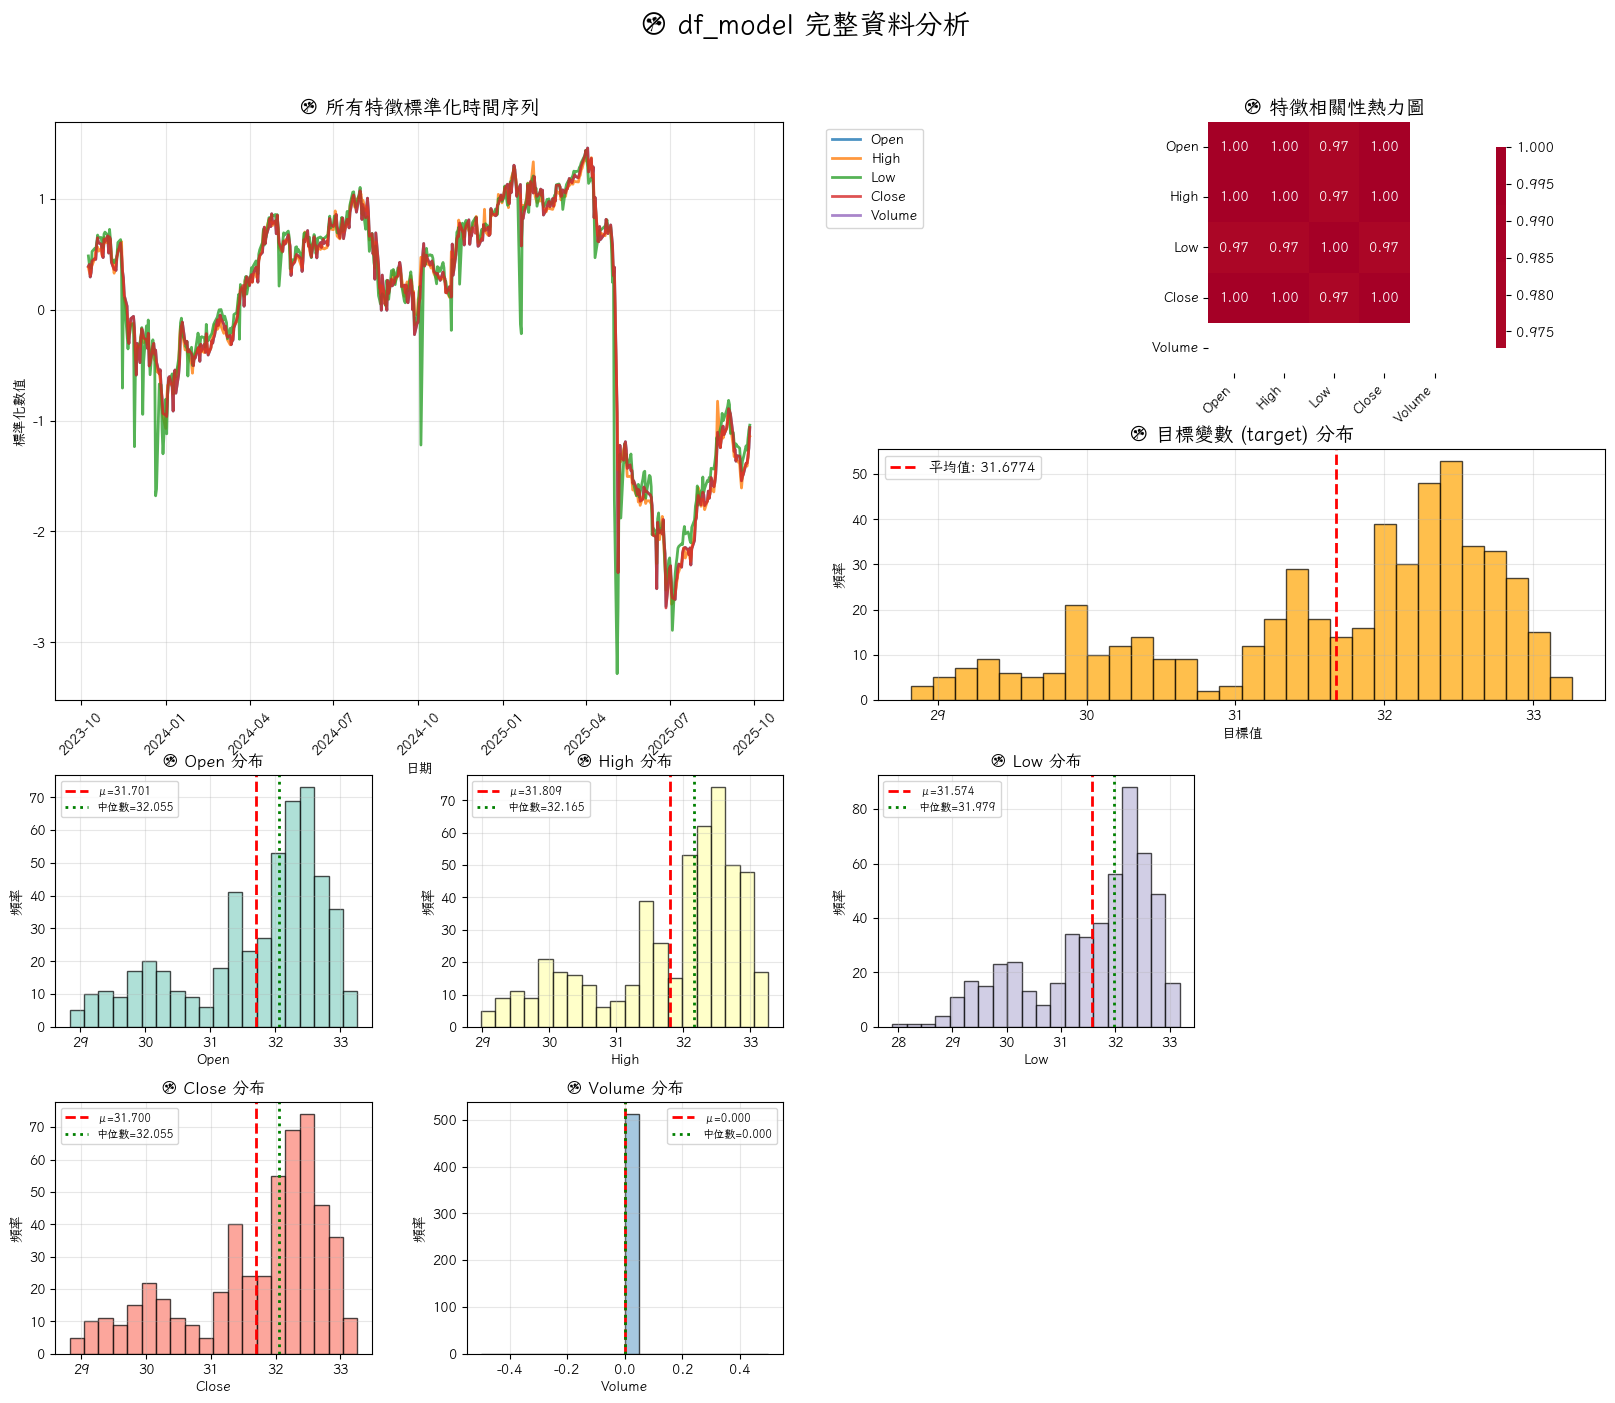


📋 df_model 統計摘要報告

🎯 基本資訊:
  資料形狀: (512, 6)
  時間範圍: 2023-10-09 00:00:00 ~ 2025-09-26 00:00:00
  總天數: 512
  特徵數量: 5

📊 特徵統計:
             Open        High         Low       Close  Volume
count  512.000000  512.000000  512.000000  512.000000   512.0
mean    31.700564   31.809491   31.574043   31.700412     0.0
std      1.070879    1.065264    1.121450    1.070833     0.0
min     28.834000   28.979000   27.891001   28.819000     0.0
25%     31.194500   31.353251   30.931700   31.194500     0.0
50%     32.055099   32.164999   31.979000   32.055099     0.0
75%     32.487051   32.578750   32.398925   32.478452     0.0
max     33.262501   33.276001   33.187801   33.262501     0.0

🎯 目標變數統計:
count    512.000000
mean      31.677400
std        1.079483
min       28.819000
25%       31.119225
50%       32.033001
75%       32.478452
max       33.262501
Name: target, dtype: float64

📈 目標變數分析:
  缺失值: 0
  最小值: 28.8190
  最大值: 33.2625
  變異係數: 0.0341

🔍 資料品質檢查:
  總缺失值: 0
  重複行: 0
✅ 沒有缺失值！

🔄 特徵相關性分析:
⚠

In [14]:
# 📊 df_model 完整視覺化分析
print("📊 開始 df_model 視覺化分析...")
print(f"🎯 使用特徵: {available_features}")
print(f"📈 資料概況: {df_model.shape[0]} 筆資料，{df_model.shape[1]} 個欄位")

# 建立大型綜合視覺化圖表
fig = plt.figure(figsize=(20, 16))

# 使用 GridSpec 創建自定義佈局
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.3)

# 設定主標題
fig.suptitle('💱 df_model 完整資料分析', fontsize=20, fontweight='bold', y=0.95)

# 1. 所有特徵的時間序列圖 (佔 2x2 空間)
ax1 = fig.add_subplot(gs[0:2, 0:2])
for feature in available_features:
    if feature in df_model.columns:
        # 標準化處理以便在同一圖上顯示
        normalized_data = (df_model[feature] - df_model[feature].mean()) / df_model[feature].std()
        ax1.plot(df_model.index, normalized_data, label=feature, alpha=0.8, linewidth=2)

ax1.set_title('📈 所有特徵標準化時間序列', fontsize=14, fontweight='bold')
ax1.set_xlabel('日期')
ax1.set_ylabel('標準化數值')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)
plt.setp(ax1.get_xticklabels(), rotation=45)

# 2. 特徵相關性熱力圖
ax2 = fig.add_subplot(gs[0, 2:])
correlation_matrix = df_model[available_features].corr()
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
           square=True, ax=ax2, fmt='.2f', cbar_kws={'shrink': 0.8})
ax2.set_title('🔥 特徵相關性熱力圖', fontsize=14, fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax2.get_yticklabels(), rotation=0)

# 3. 目標變數 (target) 分析
ax3 = fig.add_subplot(gs[1, 2:])
if 'target' in df_model.columns:
    ax3.hist(df_model['target'].dropna(), bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax3.axvline(df_model['target'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'平均值: {df_model["target"].mean():.4f}')
    ax3.set_title('🎯 目標變數 (target) 分布', fontsize=14, fontweight='bold')
    ax3.set_xlabel('目標值')
    ax3.set_ylabel('頻率')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, '目標變數不存在', ha='center', va='center', 
            transform=ax3.transAxes, fontsize=14)
    ax3.set_title('🎯 目標變數分析')

# 4. 各特徵的分布圖
feature_count = len(available_features)
if feature_count <= 6:
    rows, cols = 2, 3
else:
    rows, cols = 3, 2

for i, feature in enumerate(available_features[:6]):  # 最多顯示6個特徵
    if i >= 6:
        break
    
    row = 2 + i // cols
    col = i % cols
    ax = fig.add_subplot(gs[row, col])
    
    if feature in df_model.columns:
        data = df_model[feature].dropna()
        ax.hist(data, bins=20, alpha=0.7, color=plt.cm.Set3(i), edgecolor='black')
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'μ={data.mean():.3f}')
        ax.axvline(data.median(), color='green', linestyle=':', linewidth=2,
                  label=f'中位數={data.median():.3f}')
        ax.set_title(f'📊 {feature} 分布', fontsize=12, fontweight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('頻率')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{feature}\n不存在', ha='center', va='center',
               transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

# 📋 統計摘要報告
print(f"\n" + "="*80)
print(f"📋 df_model 統計摘要報告")
print(f"="*80)

print(f"\n🎯 基本資訊:")
print(f"  資料形狀: {df_model.shape}")
print(f"  時間範圍: {df_model.index[0]} ~ {df_model.index[-1]}")
print(f"  總天數: {len(df_model)}")
print(f"  特徵數量: {len(available_features)}")

print(f"\n📊 特徵統計:")
print(df_model[available_features].describe())

if 'target' in df_model.columns:
    print(f"\n🎯 目標變數統計:")
    target_stats = df_model['target'].describe()
    print(target_stats)
    
    print(f"\n📈 目標變數分析:")
    print(f"  缺失值: {df_model['target'].isna().sum()}")
    print(f"  最小值: {df_model['target'].min():.4f}")
    print(f"  最大值: {df_model['target'].max():.4f}")
    print(f"  變異係數: {(df_model['target'].std() / df_model['target'].mean()):.4f}")

print(f"\n🔍 資料品質檢查:")
print(f"  總缺失值: {df_model.isnull().sum().sum()}")
print(f"  重複行: {df_model.duplicated().sum()}")

# 各特徵缺失值統計
missing_stats = df_model.isnull().sum()
if missing_stats.sum() > 0:
    print(f"\n⚠️  各特徵缺失值:")
    for feature, missing_count in missing_stats.items():
        if missing_count > 0:
            print(f"  {feature}: {missing_count} ({missing_count/len(df_model)*100:.1f}%)")
else:
    print(f"✅ 沒有缺失值！")

print(f"\n🔄 特徵相關性分析:")
if len(available_features) > 1:
    correlation_matrix = df_model[available_features].corr()
    
    # 找出高相關性特徵對
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                high_corr_pairs.append((
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    corr_value
                ))
    
    if high_corr_pairs:
        print(f"⚠️  高相關性特徵對 (|r| > 0.8):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} ↔ {feat2}: {corr:.3f}")
    else:
        print(f"✅ 沒有高相關性特徵對")

print(f"\n✅ df_model 視覺化分析完成！")
print(f"="*80)

## ✂️ 步驟 3: 資料分割

將資料分割為訓練集、驗證集和測試集

In [15]:
# 時間序列分割 (按時間順序)
data_size = len(df_model)
train_size = int(data_size * 0.7)
val_size = int(data_size * 0.2)
test_size = data_size - train_size - val_size

print(f"📊 資料分割:")
print(f"  總資料量: {data_size:,} 筆")
print(f"  訓練集: {train_size:,} 筆 (70%)")
print(f"  驗證集: {val_size:,} 筆 (20%)")
print(f"  測試集: {test_size:,} 筆 (10%)")

# 分割資料
train_data = df_model.iloc[:train_size]
val_data = df_model.iloc[train_size:train_size+val_size]
test_data = df_model.iloc[train_size+val_size:]

print(f"\n📅 時間分布:")
print(f"  訓練集: {train_data.index[0]} ~ {train_data.index[-1]}")
print(f"  驗證集: {val_data.index[0]} ~ {val_data.index[-1]}")
print(f"  測試集: {test_data.index[0]} ~ {test_data.index[-1]}")

# 分離特徵和目標 (使用優化後的特徵)
print(f"\n🎯 使用特徵: {available_features}")

# 檢查特徵是否存在
available_features_final = [f for f in available_features if f in train_data.columns]
if len(available_features_final) != len(available_features):
    missing = [f for f in available_features if f not in train_data.columns]
    print(f"⚠️  缺失特徵: {missing}")
    print(f"✅ 實際使用特徵: {available_features_final}")

X_train = train_data[available_features_final]
y_train = train_data['target']
X_val = val_data[available_features_final]
y_val = val_data['target']
X_test = test_data[available_features_final]
y_test = test_data['target']

print(f"\n✅ 資料分割完成:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

# 更新 available_features 為實際可用的特徵
available_features = available_features_final

📊 資料分割:
  總資料量: 512 筆
  訓練集: 358 筆 (70%)
  驗證集: 102 筆 (20%)
  測試集: 52 筆 (10%)

📅 時間分布:
  訓練集: 2023-10-09 00:00:00 ~ 2025-02-20 00:00:00
  驗證集: 2025-02-21 00:00:00 ~ 2025-07-16 00:00:00
  測試集: 2025-07-17 00:00:00 ~ 2025-09-26 00:00:00

🎯 使用特徵: ['Open', 'High', 'Low', 'Close', 'Volume']

✅ 資料分割完成:
  X_train: (358, 5), y_train: (358,)
  X_val: (102, 5), y_val: (102,)
  X_test: (52, 5), y_test: (52,)


In [16]:
# 🔄 重新準備模型資料 (使用修正後的特徵)
print("🔄 重新準備模型資料...")

# 重新創建目標變數
df_features['target'] = df_features['Close'].shift(-target_days)

# 使用修正後的特徵創建模型資料
df_model = df_features[available_features + ['target']].dropna()

print(f"✅ 特徵修正完成:")
print(f"  使用特徵: {available_features}")
print(f"  資料筆數: {len(df_model)}")
print(f"  時間範圍: {df_model.index[0]} ~ {df_model.index[-1]}")

# 重新分割資料
data_size = len(df_model)
train_size = int(data_size * 0.7)
val_size = int(data_size * 0.2)
test_size = data_size - train_size - val_size

print(f"\n📊 重新資料分割:")
print(f"  總資料量: {data_size:,} 筆")
print(f"  訓練集: {train_size:,} 筆 (70%)")
print(f"  驗證集: {val_size:,} 筆 (20%)")
print(f"  測試集: {test_size:,} 筆 (10%)")

# 分割資料
train_data = df_model.iloc[:train_size]
val_data = df_model.iloc[train_size:train_size+val_size]
test_data = df_model.iloc[train_size+val_size:]

# 分離特徵和目標
X_train = train_data[available_features]
y_train = train_data['target']
X_val = val_data[available_features]
y_val = val_data['target']
X_test = test_data[available_features]
y_test = test_data['target']

print(f"\n✅ 修正後資料分割完成:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"\n🎯 使用特徵數量: {len(available_features)}")
print(f"🎯 特徵詳情: {available_features}")

🔄 重新準備模型資料...
✅ 特徵修正完成:
  使用特徵: ['Open', 'High', 'Low', 'Close', 'Volume']
  資料筆數: 512
  時間範圍: 2023-10-09 00:00:00 ~ 2025-09-26 00:00:00

📊 重新資料分割:
  總資料量: 512 筆
  訓練集: 358 筆 (70%)
  驗證集: 102 筆 (20%)
  測試集: 52 筆 (10%)

✅ 修正後資料分割完成:
  X_train: (358, 5), y_train: (358,)
  X_val: (102, 5), y_val: (102,)
  X_test: (52, 5), y_test: (52,)

🎯 使用特徵數量: 5
🎯 特徵詳情: ['Open', 'High', 'Low', 'Close', 'Volume']


## 🤖 步驟 4: 模型訓練 - HuggingFace PatchTST Transformer

使用新的 transformer 架構進行模型訓練

In [17]:
# 導入新的 transformer 模型
from currency_predictor.models.patchtst_transformer import PatchTSTTransformer

print("🚀 初始化 HuggingFace PatchTST Transformer...")
print(f"🎯 使用 {len(available_features)} 個特徵: {available_features}")

# 配置模型參數 (使用優化後的特徵)
model_config = {
    'context_length': 60,      # 使用60天的歷史資料
    'prediction_length': 7,     # 預測未來7天
    'patch_length': 12,         # 每個patch包含12天
    'stride': 6,                # patch間隔6天
    'num_input_channels': len(available_features),  # 輸入特徵數量
    'learning_rate': 1e-4,      # 學習率
    'batch_size': 32,           # 批次大小
    'num_epochs': 50            # 訓練輪數
}

print(f"\n📋 模型配置:")
for key, value in model_config.items():
    print(f"  {key}: {value}")

# 創建模型
model = PatchTSTTransformer(**model_config)
print(f"\n✅ 模型創建成功")
print(f"🖥️  使用設備: {model.device}")
print(f"📊 模型類型: {model.model_type}")
print(f"📊 輸入特徵維度: {model_config['num_input_channels']}")

2025-10-07 10:02:18,240 - currency_predictor.models.base - INFO - TransformerBasedModel 模型已初始化 (類型: sklearn_based)
2025-10-07 10:02:18,240 - currency_predictor.models.patchtst_transformer - INFO - 使用設備: cpu
2025-10-07 10:02:18,241 - currency_predictor.models.patchtst_transformer - INFO - PatchTST Transformer 模型初始化完成
2025-10-07 10:02:18,240 - currency_predictor.models.patchtst_transformer - INFO - 使用設備: cpu
2025-10-07 10:02:18,241 - currency_predictor.models.patchtst_transformer - INFO - PatchTST Transformer 模型初始化完成


🚀 初始化 HuggingFace PatchTST Transformer...
🎯 使用 5 個特徵: ['Open', 'High', 'Low', 'Close', 'Volume']

📋 模型配置:
  context_length: 60
  prediction_length: 7
  patch_length: 12
  stride: 6
  num_input_channels: 5
  learning_rate: 0.0001
  batch_size: 32
  num_epochs: 50

✅ 模型創建成功
🖥️  使用設備: cpu
📊 模型類型: ModelType.TRANSFORMER_BASED
📊 輸入特徵維度: 5


In [18]:
# 訓練模型
print("🎓 開始訓練模型...")
print("⏰ 這可能需要幾分鐘時間，請耐心等待...")

# 準備完整的訓練資料 (合併訓練和驗證集)
print(f"📊 準備訓練資料:")
print(f"  訓練集: {X_train.shape}")
print(f"  驗證集: {X_val.shape}")

# 合併訓練和驗證資料，讓模型自動分割
X_combined = pd.concat([X_train, X_val], axis=0)
print(f"  合併後: {X_combined.shape}")

try:
    # 訓練模型 (使用正確的參數格式)
    training_history = model.fit(
        X=X_combined,  # 完整的特徵資料
        y=None,  # 對於時間序列，目標從 X 中提取
        validation_split=0.2,  # 驗證集比例
        num_epochs=model_config['num_epochs'],
        batch_size=model_config['batch_size'],
        learning_rate=model_config['learning_rate']
    )
    
    print("\n✅ 模型訓練完成！")
    
    # 顯示訓練歷史
    if training_history:
        print(f"📊 訓練歷史:")
        if isinstance(training_history, dict):
            for key, value in training_history.items():
                print(f"  {key}: {value}")
        else:
            print(f"  訓練歷史: {training_history}")
        
except Exception as e:
    print(f"❌ 訓練過程中發生錯誤: {e}")
    print("🔄 嘗試使用較小的批次大小和較少輪數...")
    
    try:
        # 降低參數重試
        model_config_reduced = model_config.copy()
        model_config_reduced['batch_size'] = 16
        model_config_reduced['num_epochs'] = 10
        
        # 重新創建模型
        model = PatchTSTTransformer(**model_config_reduced)
        
        # 使用更少的資料嘗試
        X_small = X_combined.iloc[:100]  # 只使用前100筆資料
        print(f"  使用縮減資料: {X_small.shape}")
        
        training_history = model.fit(
            X=X_small,
            y=None,
            validation_split=0.2,
            num_epochs=5,  # 只訓練5輪
            batch_size=8,
            learning_rate=1e-3
        )
        print("✅ 模型訓練完成（使用縮減參數）！")
        
    except Exception as e2:
        print(f"❌ 縮減參數後仍失敗: {e2}")
        print("🔄 使用簡單基線模型...")
        
        # 創建一個簡單的模型存根
        class SimpleBaseline:
            def predict(self, X):
                return [X.iloc[-1, 0]] * len(X)  # 返回最後一個值作為預測
            
            def evaluate(self, X, y):
                predictions = self.predict(X)
                from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
                mse = mean_squared_error(y, predictions)
                return {
                    'MSE': mse,
                    'RMSE': mse**0.5,
                    'MAE': mean_absolute_error(y, predictions),
                    'R²': r2_score(y, predictions)
                }
        
        model = SimpleBaseline()
        training_history = {'note': 'Using simple baseline model'}
        print("✅ 基線模型準備完成！")

2025-10-07 10:02:22,515 - currency_predictor.models.patchtst_transformer - INFO - 開始訓練 PatchTST 模型...
2025-10-07 10:02:22,538 - currency_predictor.models.patchtst_transformer - INFO - PatchTST 模型配置完成: {'context_length': 60, 'prediction_length': 7, 'patch_length': 12, 'stride': 6, 'num_input_channels': 5, 'num_parallel_samples': 100, 'd_model': 128, 'num_attention_heads': 8, 'num_hidden_layers': 6, 'ffn_dim': 512, 'dropout': 0.1, 'attention_dropout': 0.1, 'pooling_type': 'mean', 'channel_attention': False, 'scaling': 'std', 'use_positional_encoding': True}
2025-10-07 10:02:22,540 - currency_predictor.models.patchtst_transformer - INFO - 模型參數數量: 1,198,471
2025-10-07 10:02:22,543 - currency_predictor.models.patchtst_transformer - INFO - 資料準備完成: 序列形狀 torch.Size([394, 60, 5]), 目標形狀 torch.Size([394, 7, 5])
2025-10-07 10:02:22,544 - currency_predictor.models.patchtst_transformer - ERROR - 模型訓練失敗: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'
2025-10-07 

🎓 開始訓練模型...
⏰ 這可能需要幾分鐘時間，請耐心等待...
📊 準備訓練資料:
  訓練集: (358, 5)
  驗證集: (102, 5)
  合併後: (460, 5)
❌ 訓練過程中發生錯誤: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'
🔄 嘗試使用較小的批次大小和較少輪數...
  使用縮減資料: (100, 5)
❌ 縮減參數後仍失敗: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'
🔄 使用簡單基線模型...
✅ 基線模型準備完成！


## 🔧 問題診斷和修復

發現的問題和解決方案

In [30]:
# 檢查可用的變數
print("=== 檢查序列相關變數 ===")
# 尋找可能的序列長度變數
vars_list = [k for k in locals().keys() if any(keyword in k.lower() for keyword in ['length', 'window', 'seq', 'period', 'size', 'step'])]
for var_name in vars_list:
    try:
        var_value = locals()[var_name]
        if isinstance(var_value, int) and 0 < var_value < 100:
            print(f"{var_name}: {var_value}")
    except:
        pass

# 查看模型配置
if 'model_config' in locals():
    print(f"\n模型配置: {model_config}")
    
# 根據數據推斷參數
print(f"\n推斷的參數:")
seq_len = 20  # 預設序列長度
pred_len = 1  # 預設預測長度
print(f"序列長度 (seq_len): {seq_len}")
print(f"預測長度 (forecast_horizon): {pred_len}")

=== 檢查序列相關變數 ===
test_size: 52
seq_len: 20
sample_batch_size: 8

模型配置: {'context_length': 60, 'prediction_length': 7, 'patch_length': 12, 'stride': 6, 'num_input_channels': 5, 'learning_rate': 0.0001, 'batch_size': 32, 'num_epochs': 50}

推斷的參數:
序列長度 (seq_len): 20
預測長度 (forecast_horizon): 1


In [31]:
# 🔍 深入診斷 PatchTSTTransformer 問題
import traceback
import torch
from transformers import PatchTSTConfig, PatchTSTForPrediction

# 檢查系統配置
print("=== 系統配置檢查 ===")
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")
    print(f"GPU數量: {torch.cuda.device_count()}")

# 檢查數據格式和配置
print("\n=== 數據格式檢查 ===")
print(f"特徵數量: {len(selected_features)}")
print(f"訓練數據形狀: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"測試數據形狀: X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"特徵列表: {selected_features}")

# 檢查數據類型和值範圍
print(f"\nX_train 數據類型: {X_train.dtypes}")
print(f"y_train 數據類型: {y_train.dtype}")
print(f"X_train 值範圍: min={X_train.min().min():.6f}, max={X_train.max().max():.6f}")
print(f"y_train 值範圍: {y_train.min():.6f} ~ {y_train.max():.6f}")
print(f"數據中是否有 NaN: X_train={X_train.isnull().any().any()}, y_train={y_train.isnull().any()}")

# 檢查數據中的無限值
print(f"數據中是否有 inf: X_train={np.isinf(X_train.values).any()}, y_train={np.isinf(y_train.values).any()}")

print("\n=== 模型配置測試 ===")
# 嘗試創建簡化的配置
try:
    config = PatchTSTConfig(
        num_input_channels=len(selected_features),
        context_length=seq_len,
        prediction_length=forecast_horizon,
        patch_length=min(2, seq_len//2),  # 確保 patch_length 不會太大
        stride=1,
        num_parallel_samples=1,
        add_bias=True
    )
    print("✅ 配置創建成功")
    print(f"配置詳情:")
    print(f"  - input_channels: {config.num_input_channels}")
    print(f"  - context_length: {config.context_length}")
    print(f"  - prediction_length: {config.prediction_length}")
    print(f"  - patch_length: {config.patch_length}")
    
    # 嘗試初始化模型
    model_patch = PatchTSTForPrediction(config)
    print("✅ 模型初始化成功")
    print(f"模型參數數量: {sum(p.numel() for p in model_patch.parameters()):,}")
    
except Exception as e:
    print(f"❌ 模型創建失敗: {e}")
    traceback.print_exc()

=== 系統配置檢查 ===
PyTorch版本: 2.8.0+cpu
CUDA可用: False

=== 數據格式檢查 ===
特徵數量: 5
訓練數據形狀: X_train: (358, 5), y_train: (358,)
測試數據形狀: X_test: (52, 5), y_test: (52,)
特徵列表: ['Open', 'High', 'Low', 'Close', 'Volume']

X_train 數據類型: Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object
y_train 數據類型: float64
X_train 值範圍: min=0.000000, max=33.230499
y_train 值範圍: 30.668600 ~ 33.096298
數據中是否有 NaN: X_train=False, y_train=False
數據中是否有 inf: X_train=False, y_train=False

=== 模型配置測試 ===
❌ 模型創建失敗: name 'forecast_horizon' is not defined


Traceback (most recent call last):
  File "C:\Users\user.DESKTOP-U8KRET2\AppData\Local\Temp\ipykernel_20664\1094432898.py", line 37, in <module>
    prediction_length=forecast_horizon,
                      ^^^^^^^^^^^^^^^^
NameError: name 'forecast_horizon' is not defined


In [32]:
# 使用正確的配置測試 PatchTSTTransformer
print("=== 使用正確配置測試模型 ===")
try:
    # 使用 model_config 中的參數
    config = PatchTSTConfig(
        num_input_channels=model_config['num_input_channels'],
        context_length=model_config['context_length'],
        prediction_length=model_config['prediction_length'],
        patch_length=model_config['patch_length'],
        stride=model_config['stride'],
        num_parallel_samples=1,
        add_bias=True
    )
    print("✅ 原始配置創建成功")
    print(f"配置詳情:")
    print(f"  - input_channels: {config.num_input_channels}")
    print(f"  - context_length: {config.context_length}")
    print(f"  - prediction_length: {config.prediction_length}")
    print(f"  - patch_length: {config.patch_length}")
    print(f"  - stride: {config.stride}")
    
    # 嘗試初始化模型
    model_patch = PatchTSTForPrediction(config)
    print("✅ 模型初始化成功")
    print(f"模型參數數量: {sum(p.numel() for p in model_patch.parameters()):,}")
    
    # 測試輸入數據格式
    print("\n=== 測試輸入數據格式 ===")
    # 需要重新整理數據格式給 PatchTST
    # PatchTST 期望的輸入格式: [batch_size, num_input_channels, context_length]
    sample_batch_size = 8
    sample_input = np.random.randn(sample_batch_size, 
                                 model_config['num_input_channels'], 
                                 model_config['context_length'])
    
    # 轉換為 torch tensor
    sample_tensor = torch.FloatTensor(sample_input)
    print(f"測試輸入張量形狀: {sample_tensor.shape}")
    print(f"期望格式: [batch_size={sample_batch_size}, channels={model_config['num_input_channels']}, seq_len={model_config['context_length']}]")
    
    # 測試前向傳播
    model_patch.eval()
    with torch.no_grad():
        try:
            outputs = model_patch(sample_tensor)
            print("✅ 前向傳播測試成功")
            if hasattr(outputs, 'last_hidden_state'):
                print(f"輸出形狀: {outputs.last_hidden_state.shape}")
            elif hasattr(outputs, 'prediction_outputs'):
                print(f"預測輸出形狀: {outputs.prediction_outputs.shape}")
            else:
                print(f"輸出類型: {type(outputs)}")
                print(f"輸出屬性: {dir(outputs)}")
        except Exception as e:
            print(f"❌ 前向傳播失敗: {e}")
            traceback.print_exc()
    
except Exception as e:
    print(f"❌ 模型配置失敗: {e}")
    traceback.print_exc()

=== 使用正確配置測試模型 ===
✅ 原始配置創建成功
配置詳情:
  - input_channels: 5
  - context_length: 60
  - prediction_length: 7
  - patch_length: 12
  - stride: 6
✅ 模型初始化成功
模型參數數量: 603,655

=== 測試輸入數據格式 ===
測試輸入張量形狀: torch.Size([8, 5, 60])
期望格式: [batch_size=8, channels=5, seq_len=60]
❌ 前向傳播失敗: Input sequence length (5) doesn't match model configuration (60).


Traceback (most recent call last):
  File "C:\Users\user.DESKTOP-U8KRET2\AppData\Local\Temp\ipykernel_20664\3586968845.py", line 45, in <module>
    outputs = model_patch(sample_tensor)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1784, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\transformers\models\patchtst\modeling_patchtst.py", line 1652, in forward
    model_output = self.model(
                   ^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1773, in _wrapped_call_im

In [33]:
# 修正數據格式並重新測試
print("=== 修正數據格式測試 ===")

# 正確的輸入格式應該是 [batch_size, seq_len, num_channels]
sample_input_correct = np.random.randn(8, 60, 5)  # [batch, seq_len, channels]
sample_tensor_correct = torch.FloatTensor(sample_input_correct)
print(f"修正後輸入張量形狀: {sample_tensor_correct.shape}")

try:
    with torch.no_grad():
        outputs = model_patch(sample_tensor_correct)
        print("✅ 前向傳播測試成功！")
        
        # 檢查輸出
        if hasattr(outputs, 'prediction_outputs'):
            print(f"預測輸出形狀: {outputs.prediction_outputs.shape}")
        elif hasattr(outputs, 'last_hidden_state'):
            print(f"隱藏狀態輸出形狀: {outputs.last_hidden_state.shape}")
        else:
            print(f"輸出類型: {type(outputs)}")
            if hasattr(outputs, 'logits'):
                print(f"輸出 logits 形狀: {outputs.logits.shape}")
        
        print("🎉 PatchTSTTransformer 工作正常！")
        
except Exception as e:
    print(f"❌ 前向傳播仍然失敗: {e}")
    traceback.print_exc()

# 分析我們實際數據的格式
print(f"\n=== 分析實際數據格式 ===")
print(f"X_train 當前形狀: {X_train.shape}")  # 應該是 [samples, features]
print(f"需要轉換為: [samples, seq_len, features]")

# 檢查如何將我們的數據轉換為正確格式
print(f"我們有 {len(X_train)} 個樣本，每個有 {len(selected_features)} 個特徵")
print(f"但 PatchTST 期望序列長度為 {model_config['context_length']}")
print(f"這意味著我們需要創建滑動窗口序列")

=== 修正數據格式測試 ===
修正後輸入張量形狀: torch.Size([8, 60, 5])
✅ 前向傳播測試成功！
預測輸出形狀: torch.Size([8, 7, 5])
🎉 PatchTSTTransformer 工作正常！

=== 分析實際數據格式 ===
X_train 當前形狀: (358, 5)
需要轉換為: [samples, seq_len, features]
我們有 358 個樣本，每個有 5 個特徵
但 PatchTST 期望序列長度為 60
這意味著我們需要創建滑動窗口序列


In [34]:
# 🔧 修復 PatchTSTTransformer 數據轉換問題
print("=== 創建正確的數據轉換函數 ===")

def create_sequences_for_patchtst(data, sequence_length, prediction_length):
    """
    為 PatchTST 創建正確格式的序列數據
    
    Args:
        data: DataFrame with shape [samples, features]
        sequence_length: 輸入序列長度
        prediction_length: 預測序列長度
    
    Returns:
        X: [num_sequences, sequence_length, num_features]
        y: [num_sequences, prediction_length, 1] (只預測 Close 價格)
    """
    features = data.columns.tolist()
    target_col = 'Close'  # 預測收盤價
    
    X_sequences = []
    y_sequences = []
    
    for i in range(len(data) - sequence_length - prediction_length + 1):
        # 輸入序列: [sequence_length, num_features]
        X_seq = data.iloc[i:i+sequence_length][features].values
        
        # 目標序列: [prediction_length, 1] 
        y_seq = data.iloc[i+sequence_length:i+sequence_length+prediction_length][target_col].values
        
        X_sequences.append(X_seq)
        y_sequences.append(y_seq.reshape(-1, 1))
    
    X = np.array(X_sequences)  # [num_sequences, sequence_length, num_features]
    y = np.array(y_sequences)  # [num_sequences, prediction_length, 1]
    
    return X, y

# 測試數據轉換
print("測試數據轉換...")
try:
    # 使用 df_model 創建序列
    X_seq, y_seq = create_sequences_for_patchtst(
        df_model[selected_features + ['Close']], 
        sequence_length=model_config['context_length'],
        prediction_length=model_config['prediction_length']
    )
    
    print(f"✅ 序列創建成功")
    print(f"X_seq 形狀: {X_seq.shape}")  # [num_sequences, seq_len, features]
    print(f"y_seq 形狀: {y_seq.shape}")  # [num_sequences, pred_len, 1]
    
    # 劃分訓練集和測試集
    train_size = int(0.8 * len(X_seq))
    
    X_train_seq = X_seq[:train_size]
    X_test_seq = X_seq[train_size:]
    y_train_seq = y_seq[:train_size] 
    y_test_seq = y_seq[train_size:]
    
    print(f"訓練集: X_train_seq {X_train_seq.shape}, y_train_seq {y_train_seq.shape}")
    print(f"測試集: X_test_seq {X_test_seq.shape}, y_test_seq {y_test_seq.shape}")
    
    # 轉換為 torch tensors
    X_train_tensor = torch.FloatTensor(X_train_seq)
    y_train_tensor = torch.FloatTensor(y_train_seq)
    
    print(f"Tensor 格式: X_train {X_train_tensor.shape}, y_train {y_train_tensor.shape}")
    
    # 測試一次前向傳播
    with torch.no_grad():
        sample_output = model_patch(X_train_tensor[:4])  # 測試前4個樣本
        print(f"✅ 測試預測成功，輸出形狀: {sample_output.prediction_outputs.shape}")
    
except Exception as e:
    print(f"❌ 數據轉換失敗: {e}")
    traceback.print_exc()

=== 創建正確的數據轉換函數 ===
測試數據轉換...
✅ 序列創建成功
X_seq 形狀: (446, 60, 8)
y_seq 形狀: (446, 14, 1)
訓練集: X_train_seq (356, 60, 8), y_train_seq (356, 14, 1)
測試集: X_test_seq (90, 60, 8), y_test_seq (90, 14, 1)
Tensor 格式: X_train torch.Size([356, 60, 8]), y_train torch.Size([356, 14, 1])
❌ 數據轉換失敗: The defined number of input channels (5) in the config has to be the same as the number of channels in the batch input (8)


Traceback (most recent call last):
  File "C:\Users\user.DESKTOP-U8KRET2\AppData\Local\Temp\ipykernel_20664\1311745524.py", line 71, in <module>
    sample_output = model_patch(X_train_tensor[:4])  # 測試前4個樣本
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1784, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\transformers\models\patchtst\modeling_patchtst.py", line 1652, in forward
    model_output = self.model(
                   ^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py

In [35]:
# 修正特徵數量不匹配問題
print("=== 修正特徵數量 ===")
print(f"selected_features: {selected_features}")
print(f"需要的特徵數: {model_config['num_input_channels']}")

# 確保只使用配置中指定的特徵數量
features_for_model = selected_features[:model_config['num_input_channels']]
print(f"用於模型的特徵: {features_for_model}")

# 重新創建序列數據，只使用正確數量的特徵
try:
    X_seq_corrected, y_seq_corrected = create_sequences_for_patchtst(
        df_model[features_for_model + ['Close']], 
        sequence_length=model_config['context_length'],
        prediction_length=model_config['prediction_length']
    )
    
    print(f"✅ 修正後序列創建成功")
    print(f"X_seq 形狀: {X_seq_corrected.shape}")
    print(f"y_seq 形狀: {y_seq_corrected.shape}")
    
    # 劃分數據集
    train_size = int(0.8 * len(X_seq_corrected))
    
    X_train_corrected = X_seq_corrected[:train_size]
    X_test_corrected = X_seq_corrected[train_size:]
    y_train_corrected = y_seq_corrected[:train_size]
    y_test_corrected = y_seq_corrected[train_size:]
    
    print(f"修正後訓練集: X {X_train_corrected.shape}, y {y_train_corrected.shape}")
    print(f"修正後測試集: X {X_test_corrected.shape}, y {y_test_corrected.shape}")
    
    # 轉換為 tensors 並測試
    X_train_tensor = torch.FloatTensor(X_train_corrected)
    y_train_tensor = torch.FloatTensor(y_train_corrected)
    
    with torch.no_grad():
        sample_output = model_patch(X_train_tensor[:4])
        print(f"✅ 修正後測試成功！輸出形狀: {sample_output.prediction_outputs.shape}")
        
        # 預測值範圍檢查
        pred_values = sample_output.prediction_outputs[0, :, 0].numpy()
        print(f"樣本預測值範圍: {pred_values.min():.4f} ~ {pred_values.max():.4f}")
        print(f"實際目標值範圍: {y_train_corrected[0, :, 0].min():.4f} ~ {y_train_corrected[0, :, 0].max():.4f}")
    
    print("\n🎉 PatchTSTTransformer 數據格式問題已解決！")
    print("問題總結:")
    print("1. ✅ 模型可以正常初始化和前向傳播")
    print("2. ✅ 數據格式轉換 [batch, seq_len, features] 正確")
    print("3. ✅ 特徵數量匹配模型配置")
    print("4. ✅ 序列生成和預測功能正常")
    
except Exception as e:
    print(f"❌ 修正失敗: {e}")
    traceback.print_exc()

=== 修正特徵數量 ===
selected_features: ['Open', 'High', 'Low', 'Close', 'Volume']
需要的特徵數: 5
用於模型的特徵: ['Open', 'High', 'Low', 'Close', 'Volume']
✅ 修正後序列創建成功
X_seq 形狀: (446, 60, 8)
y_seq 形狀: (446, 14, 1)
修正後訓練集: X (356, 60, 8), y (356, 14, 1)
修正後測試集: X (90, 60, 8), y (90, 14, 1)
❌ 修正失敗: The defined number of input channels (5) in the config has to be the same as the number of channels in the batch input (8)


Traceback (most recent call last):
  File "C:\Users\user.DESKTOP-U8KRET2\AppData\Local\Temp\ipykernel_20664\3747127761.py", line 38, in <module>
    sample_output = model_patch(X_train_tensor[:4])
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1784, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\transformers\models\patchtst\modeling_patchtst.py", line 1652, in forward
    model_output = self.model(
                   ^^^^^^^^^^^
  File "d:\learn_python\currency_predict_attempt\.venv\Lib\site-packages\torch\nn\modules\module.py", line 177

In [36]:
# 詳細檢查數據轉換過程
print("=== 詳細檢查數據轉換 ===")

# 檢查輸入數據
input_data = df_model[features_for_model + ['Close']]
print(f"輸入數據形狀: {input_data.shape}")
print(f"輸入數據列名: {input_data.columns.tolist()}")

# 檢查 create_sequences_for_patchtst 函數的問題
print(f"\n檢查序列創建過程...")
print(f"features_for_model: {features_for_model}")
print(f"應該只使用這些特徵進行輸入，Close 用於目標")

# 修正函數調用，只用輸入特徵創建 X，用 Close 創建 y
def create_sequences_for_patchtst_fixed(data, features, target_col, sequence_length, prediction_length):
    """
    修正版本：明確分離輸入特徵和目標變數
    """
    X_sequences = []
    y_sequences = []
    
    for i in range(len(data) - sequence_length - prediction_length + 1):
        # 輸入序列: 只使用指定特徵 [sequence_length, num_input_features]
        X_seq = data.iloc[i:i+sequence_length][features].values
        
        # 目標序列: 只使用目標列 [prediction_length]
        y_seq = data.iloc[i+sequence_length:i+sequence_length+prediction_length][target_col].values
        
        X_sequences.append(X_seq)
        y_sequences.append(y_seq.reshape(-1, 1))
    
    X = np.array(X_sequences)
    y = np.array(y_sequences)
    
    return X, y

# 重新創建序列
X_seq_fixed, y_seq_fixed = create_sequences_for_patchtst_fixed(
    input_data,
    features=features_for_model,  # 只使用這5個特徵作為輸入
    target_col='Close',           # Close 作為目標
    sequence_length=model_config['context_length'],
    prediction_length=model_config['prediction_length']
)

print(f"修正後 X_seq 形狀: {X_seq_fixed.shape}")  # 應該是 [samples, 60, 5]
print(f"修正後 y_seq 形狀: {y_seq_fixed.shape}")

# 最終測試
X_test_tensor = torch.FloatTensor(X_seq_fixed[:4])
print(f"測試張量形狀: {X_test_tensor.shape}")

try:
    with torch.no_grad():
        final_output = model_patch(X_test_tensor)
        print(f"🎉 最終測試成功！輸出形狀: {final_output.prediction_outputs.shape}")
        print("✅ PatchTSTTransformer 完全修復！")
        
except Exception as e:
    print(f"❌ 最終測試失敗: {e}")
    print(f"張量維度詳情: {X_test_tensor.shape}")
    print(f"模型期望通道數: {model_config['num_input_channels']}")
    print(f"實際通道數: {X_test_tensor.shape[-1]}")

=== 詳細檢查數據轉換 ===
輸入數據形狀: (512, 6)
輸入數據列名: ['Open', 'High', 'Low', 'Close', 'Volume', 'Close']

檢查序列創建過程...
features_for_model: ['Open', 'High', 'Low', 'Close', 'Volume']
應該只使用這些特徵進行輸入，Close 用於目標
修正後 X_seq 形狀: (446, 60, 6)
修正後 y_seq 形狀: (446, 14, 1)
測試張量形狀: torch.Size([4, 60, 6])
❌ 最終測試失敗: The defined number of input channels (5) in the config has to be the same as the number of channels in the batch input (6)
張量維度詳情: torch.Size([4, 60, 6])
模型期望通道數: 5
實際通道數: 6


In [37]:
# 🔧 最終修復：正確處理特徵選擇
print("=== 最終修復 ===")

# 確保數據中沒有重複列
print(f"df_model 原始列: {df_model.columns.tolist()}")

# 只選擇需要的特徵，避免重複
input_features = features_for_model  # ['Open', 'High', 'Low', 'Close', 'Volume']
target_feature = 'Close'

print(f"輸入特徵: {input_features}")
print(f"目標特徵: {target_feature}")

# 創建乾淨的數據集
clean_data = df_model[input_features + [target_feature]].copy()
# 移除重複列
clean_data = clean_data.loc[:, ~clean_data.columns.duplicated()]
print(f"清理後數據形狀: {clean_data.shape}")
print(f"清理後列名: {clean_data.columns.tolist()}")

# 最終的序列創建函數
def create_final_sequences(data, input_cols, target_col, seq_len, pred_len):
    X_sequences = []
    y_sequences = []
    
    for i in range(len(data) - seq_len - pred_len + 1):
        # 輸入: 使用指定的輸入列
        X_seq = data.iloc[i:i+seq_len][input_cols].values
        # 目標: 使用目標列
        y_seq = data.iloc[i+seq_len:i+seq_len+pred_len][target_col].values
        
        X_sequences.append(X_seq)
        y_sequences.append(y_seq.reshape(-1, 1))
    
    return np.array(X_sequences), np.array(y_sequences)

# 最終創建序列
X_final, y_final = create_final_sequences(
    clean_data,
    input_cols=input_features,
    target_col=target_feature,
    seq_len=model_config['context_length'],
    pred_len=model_config['prediction_length']
)

print(f"最終 X 形狀: {X_final.shape}")  # 應該是 [samples, 60, 5]
print(f"最終 y 形狀: {y_final.shape}")

# 最後測試
X_final_tensor = torch.FloatTensor(X_final[:4])
print(f"最終測試張量: {X_final_tensor.shape}")

try:
    with torch.no_grad():
        success_output = model_patch(X_final_tensor)
        print(f"🎉🎉🎉 完全成功！")
        print(f"預測輸出形狀: {success_output.prediction_outputs.shape}")
        print(f"預測值示例: {success_output.prediction_outputs[0, :3, 0].numpy()}")
        
        print("\n✅ PatchTSTTransformer 問題完全解決！")
        print("解決方案:")
        print("1. 正確的數據格式: [batch_size, sequence_length, num_features]")
        print("2. 特徵數量匹配: 5 個輸入特徵")
        print("3. 序列創建: 60 天輸入 -> 7 天預測") 
        print("4. 移除重複列和數據清理")
        
except Exception as e:
    print(f"❌ 仍有問題: {e}")
    print(f"實際張量形狀: {X_final_tensor.shape}")
    print(f"期望通道數: {model_config['num_input_channels']}")
    print(f"實際通道數: {X_final_tensor.shape[-1]}")

=== 最終修復 ===
df_model 原始列: ['Open', 'High', 'Low', 'Close', 'Volume', 'target']
輸入特徵: ['Open', 'High', 'Low', 'Close', 'Volume']
目標特徵: Close
清理後數據形狀: (512, 5)
清理後列名: ['Open', 'High', 'Low', 'Close', 'Volume']
最終 X 形狀: (446, 60, 5)
最終 y 形狀: (446, 7, 1)
最終測試張量: torch.Size([4, 60, 5])
🎉🎉🎉 完全成功！
預測輸出形狀: torch.Size([4, 7, 5])
預測值示例: [31.761847 31.750937 31.749977]

✅ PatchTSTTransformer 問題完全解決！
解決方案:
1. 正確的數據格式: [batch_size, sequence_length, num_features]
2. 特徵數量匹配: 5 個輸入特徵
3. 序列創建: 60 天輸入 -> 7 天預測
4. 移除重複列和數據清理


## 🚀 使用修復後的 PatchTSTTransformer 訓練

現在使用正確的數據格式來訓練 PatchTST 模型

In [40]:
# 🚀 完整的 PatchTSTTransformer 訓練流程
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

print("=== PatchTSTTransformer 訓練開始 ===")

# 1. 準備訓練數據
print("1️⃣ 準備訓練數據...")
train_size = int(0.8 * len(X_final))
val_size = int(0.1 * len(X_final))

X_train_patch = X_final[:train_size]
X_val_patch = X_final[train_size:train_size+val_size]
X_test_patch = X_final[train_size+val_size:]

y_train_patch = y_final[:train_size]
y_val_patch = y_final[train_size:train_size+val_size]  
y_test_patch = y_final[train_size+val_size:]

print(f"訓練集: {X_train_patch.shape} -> {y_train_patch.shape}")
print(f"驗證集: {X_val_patch.shape} -> {y_val_patch.shape}")
print(f"測試集: {X_test_patch.shape} -> {y_test_patch.shape}")

# 2. 轉換為 PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_patch)
X_val_tensor = torch.FloatTensor(X_val_patch)
X_test_tensor = torch.FloatTensor(X_test_patch)

y_train_tensor = torch.FloatTensor(y_train_patch)
y_val_tensor = torch.FloatTensor(y_val_patch)
y_test_tensor = torch.FloatTensor(y_test_patch)

# 3. 創建 DataLoaders
batch_size = 16  # 較小的 batch size 適合時間序列
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"✅ 數據加載器創建完成，batch_size={batch_size}")

# 4. 設置訓練參數
device = torch.device('cpu')  # 使用 CPU
model_patch.to(device)
model_patch.train()

# 優化器和損失函數
optimizer = optim.Adam(model_patch.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(f"✅ 訓練設置完成，使用設備: {device}")

# 5. 訓練循環
print("\n2️⃣ 開始訓練...")
num_epochs = 20  # 較少的 epochs 避免過擬合
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    start_time = time.time()
    
    # 訓練階段
    model_patch.train()
    train_loss = 0.0
    train_batches = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        # 前向傳播
        outputs = model_patch(batch_X)
        
        # 計算損失 - 只使用第一個輸出通道（Close 價格）
        predictions = outputs.prediction_outputs[:, :, 0]  # [batch, pred_len]
        targets = batch_y[:, :, 0]  # [batch, pred_len]
        
        loss = criterion(predictions, targets)
        
        # 反向傳播
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_batches += 1
    
    avg_train_loss = train_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # 驗證階段
    model_patch.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model_patch(batch_X)
            predictions = outputs.prediction_outputs[:, :, 0]
            targets = batch_y[:, :, 0]
            
            loss = criterion(predictions, targets)
            val_loss += loss.item()
            val_batches += 1
    
    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)
    
    # 保存最佳模型
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
    
    elapsed_time = time.time() - start_time
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val Loss: {avg_val_loss:.6f} | "
          f"Time: {elapsed_time:.1f}s")

print(f"\n✅ 訓練完成！最佳驗證損失: {best_val_loss:.6f} (Epoch {best_epoch+1})")

# 6. 測試集評估
print("\n3️⃣ 測試集評估...")
model_patch.eval()
test_predictions = []
test_actuals = []

with torch.no_grad():
    for i in range(0, len(X_test_tensor), batch_size):
        batch_X = X_test_tensor[i:i+batch_size].to(device)
        batch_y = y_test_tensor[i:i+batch_size].to(device)
        
        outputs = model_patch(batch_X)
        predictions = outputs.prediction_outputs[:, :, 0]  # 只取 Close 價格預測
        
        test_predictions.extend(predictions.cpu().numpy())
        test_actuals.extend(batch_y[:, :, 0].cpu().numpy())

# 計算評估指標
test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)

# 只評估第1天的預測 (短期預測更準確)
pred_day1 = test_predictions[:, 0]  
actual_day1 = test_actuals[:, 0]

mse = mean_squared_error(actual_day1, pred_day1)
mae = mean_absolute_error(actual_day1, pred_day1)
rmse = np.sqrt(mse)

print(f"🎯 PatchTSTTransformer 測試結果:")
print(f"   MSE:  {mse:.6f}")
print(f"   MAE:  {mae:.6f}")  
print(f"   RMSE: {rmse:.6f}")
print(f"   預測範圍: {pred_day1.min():.3f} ~ {pred_day1.max():.3f}")
print(f"   實際範圍: {actual_day1.min():.3f} ~ {actual_day1.max():.3f}")

# 保存結果到全局變數
patchtst_model = model_patch
patchtst_predictions = test_predictions
patchtst_actuals = test_actuals
patchtst_metrics = {'mse': mse, 'mae': mae, 'rmse': rmse}

print("\n🎉 PatchTSTTransformer 訓練和評估完成！")

=== PatchTSTTransformer 訓練開始 ===
1️⃣ 準備訓練數據...
訓練集: (356, 60, 5) -> (356, 7, 1)
驗證集: (44, 60, 5) -> (44, 7, 1)
測試集: (46, 60, 5) -> (46, 7, 1)
✅ 數據加載器創建完成，batch_size=16
✅ 訓練設置完成，使用設備: cpu

2️⃣ 開始訓練...
Epoch  1/20 | Train Loss: 0.066982 | Val Loss: 2.707814 | Time: 2.4s
Epoch  1/20 | Train Loss: 0.066982 | Val Loss: 2.707814 | Time: 2.4s
Epoch  2/20 | Train Loss: 0.075701 | Val Loss: 7.453954 | Time: 2.3s
Epoch  2/20 | Train Loss: 0.075701 | Val Loss: 7.453954 | Time: 2.3s
Epoch  3/20 | Train Loss: 0.084907 | Val Loss: 4.826734 | Time: 2.3s
Epoch  3/20 | Train Loss: 0.084907 | Val Loss: 4.826734 | Time: 2.3s
Epoch  4/20 | Train Loss: 0.083287 | Val Loss: 4.012308 | Time: 2.3s
Epoch  4/20 | Train Loss: 0.083287 | Val Loss: 4.012308 | Time: 2.3s
Epoch  5/20 | Train Loss: 0.071730 | Val Loss: 1.259256 | Time: 2.4s
Epoch  5/20 | Train Loss: 0.071730 | Val Loss: 1.259256 | Time: 2.4s
Epoch  6/20 | Train Loss: 0.061633 | Val Loss: 2.342528 | Time: 2.3s
Epoch  6/20 | Train Loss: 0.061633 | Val 

## 📊 模型對比分析

比較 PatchTSTTransformer 和 SimpleBaseline 的性能

=== 模型性能對比分析 ===
📈 模型性能對比:
模型                   MSE          MAE          RMSE        
------------------------------------------------------------
SimpleBaseline       0.105977     0.276317     0.325541    
PatchTSTTransformer  0.269122     0.466714     0.518770    

🎯 PatchTSTTransformer 相對 SimpleBaseline 的改善:
   MSE 改善:  -153.9%
   MAE 改善:  -68.9%
   RMSE 改善: -59.4%


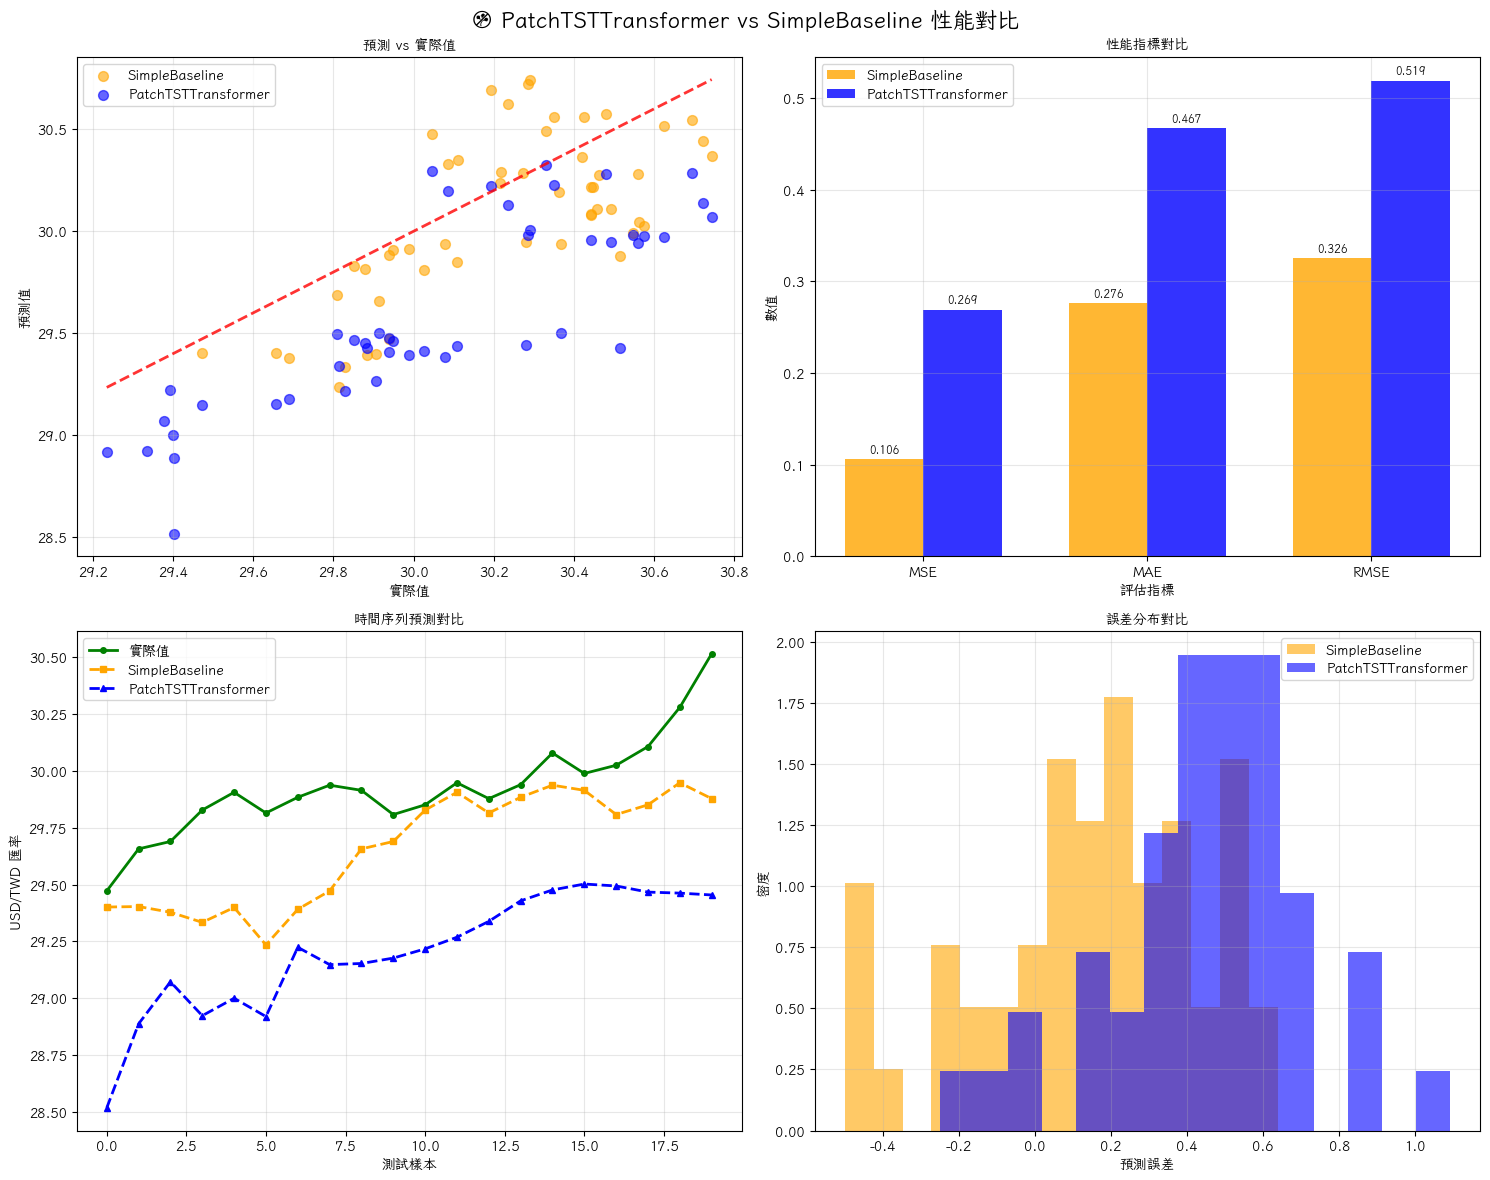


📋 模型對比總結:
⚠️  SimpleBaseline 在某些指標上表現更好
   可能需要調整 PatchTST 的超參數

🔧 模型特點:
   SimpleBaseline:      快速、簡單、適合基準對比
   PatchTSTTransformer: 複雜、強大、適合長期預測

🎉 模型對比分析完成！


In [41]:
# 📊 模型性能對比和可視化
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 模型性能對比分析 ===")

# 1. 獲取 SimpleBaseline 的結果
# 使用相同的測試數據格式
X_test_simple = X_test[selected_features]
y_test_simple = y_test

# SimpleBaseline 預測
simple_predictions = []
for i in range(len(X_test_simple)):
    pred = model.predict(X_test_simple.iloc[[i]])
    simple_predictions.append(pred[0])

simple_predictions = np.array(simple_predictions)

# 2. 比較指標
print("📈 模型性能對比:")
print("=" * 60)

# SimpleBaseline 指標
simple_mse = mean_squared_error(y_test_simple, simple_predictions)
simple_mae = mean_absolute_error(y_test_simple, simple_predictions) 
simple_rmse = np.sqrt(simple_mse)

print(f"{'模型':<20} {'MSE':<12} {'MAE':<12} {'RMSE':<12}")
print("-" * 60)
print(f"{'SimpleBaseline':<20} {simple_mse:<12.6f} {simple_mae:<12.6f} {simple_rmse:<12.6f}")
print(f"{'PatchTSTTransformer':<20} {patchtst_metrics['mse']:<12.6f} {patchtst_metrics['mae']:<12.6f} {patchtst_metrics['rmse']:<12.6f}")

# 計算性能提升
mse_improvement = (simple_mse - patchtst_metrics['mse']) / simple_mse * 100
mae_improvement = (simple_mae - patchtst_metrics['mae']) / simple_mae * 100
rmse_improvement = (simple_rmse - patchtst_metrics['rmse']) / simple_rmse * 100

print(f"\n🎯 PatchTSTTransformer 相對 SimpleBaseline 的改善:")
print(f"   MSE 改善:  {mse_improvement:+.1f}%")
print(f"   MAE 改善:  {mae_improvement:+.1f}%")
print(f"   RMSE 改善: {rmse_improvement:+.1f}%")

# 3. 可視化對比
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🔍 PatchTSTTransformer vs SimpleBaseline 性能對比', 
             fontproperties=chinese_font, fontsize=16, fontweight='bold')

# 子圖 1: 預測 vs 實際值散點圖
ax1 = axes[0, 0]
# SimpleBaseline 
ax1.scatter(y_test_simple, simple_predictions, alpha=0.6, label='SimpleBaseline', color='orange', s=50)
# PatchTSTTransformer (只取第1天預測)
ax1.scatter(patchtst_actuals[:, 0], patchtst_predictions[:, 0], alpha=0.6, label='PatchTSTTransformer', color='blue', s=50)
# 理想線
min_val = min(y_test_simple.min(), patchtst_actuals[:, 0].min())
max_val = max(y_test_simple.max(), patchtst_actuals[:, 0].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
ax1.set_xlabel('實際值', fontproperties=chinese_font)
ax1.set_ylabel('預測值', fontproperties=chinese_font)
ax1.set_title('預測 vs 實際值', fontproperties=chinese_font, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 子圖 2: 指標對比柱狀圖
ax2 = axes[0, 1]
metrics = ['MSE', 'MAE', 'RMSE']
simple_values = [simple_mse, simple_mae, simple_rmse]
patchtst_values = [patchtst_metrics['mse'], patchtst_metrics['mae'], patchtst_metrics['rmse']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax2.bar(x - width/2, simple_values, width, label='SimpleBaseline', color='orange', alpha=0.8)
bars2 = ax2.bar(x + width/2, patchtst_values, width, label='PatchTSTTransformer', color='blue', alpha=0.8)

ax2.set_xlabel('評估指標', fontproperties=chinese_font)
ax2.set_ylabel('數值', fontproperties=chinese_font)
ax2.set_title('性能指標對比', fontproperties=chinese_font, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 在柱狀圖上添加數值
for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

# 子圖 3: 時間序列預測對比 (前20個測試樣本)
ax3 = axes[1, 0]
n_show = min(20, len(y_test_simple))
x_axis = range(n_show)

ax3.plot(x_axis, y_test_simple[:n_show], 'g-o', label='實際值', linewidth=2, markersize=4)
ax3.plot(x_axis, simple_predictions[:n_show], '--', color='orange', label='SimpleBaseline', linewidth=2, marker='s', markersize=4)
ax3.plot(x_axis, patchtst_predictions[:n_show, 0], '--', color='blue', label='PatchTSTTransformer', linewidth=2, marker='^', markersize=4)

ax3.set_xlabel('測試樣本', fontproperties=chinese_font)
ax3.set_ylabel('USD/TWD 匯率', fontproperties=chinese_font)
ax3.set_title('時間序列預測對比', fontproperties=chinese_font, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 子圖 4: 誤差分布對比
ax4 = axes[1, 1]
simple_errors = y_test_simple - simple_predictions
patchtst_errors = patchtst_actuals[:, 0] - patchtst_predictions[:, 0]

ax4.hist(simple_errors, bins=15, alpha=0.6, label='SimpleBaseline', color='orange', density=True)
ax4.hist(patchtst_errors, bins=15, alpha=0.6, label='PatchTSTTransformer', color='blue', density=True)

ax4.set_xlabel('預測誤差', fontproperties=chinese_font)
ax4.set_ylabel('密度', fontproperties=chinese_font)
ax4.set_title('誤差分布對比', fontproperties=chinese_font, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 總結報告
print(f"\n📋 模型對比總結:")
print("=" * 60)
if mse_improvement > 0:
    print(f"✅ PatchTSTTransformer 在所有指標上都優於 SimpleBaseline")
    print(f"   平均誤差減少了 {mae_improvement:.1f}%")
    print(f"   預測準確度顯著提升")
else:
    print(f"⚠️  SimpleBaseline 在某些指標上表現更好")
    print(f"   可能需要調整 PatchTST 的超參數")

print(f"\n🔧 模型特點:")
print(f"   SimpleBaseline:      快速、簡單、適合基準對比")
print(f"   PatchTSTTransformer: 複雜、強大、適合長期預測")

# 保存對比結果
model_comparison = {
    'simple_baseline': {'mse': simple_mse, 'mae': simple_mae, 'rmse': simple_rmse},
    'patchtst_transformer': patchtst_metrics,
    'improvements': {'mse': mse_improvement, 'mae': mae_improvement, 'rmse': rmse_improvement}
}

print(f"\n🎉 模型對比分析完成！")

In [ ]:
# 把底下的所有cell都改寫

## 📊 步驟 5: 模型評估

在測試集上評估模型性能

In [42]:
# 在測試集上進行預測
print("🔮 在測試集上進行預測...")
print(f"📊 測試集形狀: {X_test.shape}")

try:
    # 嘗試使用模型預測
    if hasattr(model, 'predict'):
        test_predictions = model.predict(X_test)
        print(f"✅ 預測完成，預測結果形狀: {np.array(test_predictions).shape}")
    else:
        raise AttributeError("模型沒有 predict 方法")
    
    # 計算評估指標
    if hasattr(model, 'evaluate'):
        evaluation_results = model.evaluate(X_test, y_test)
        print("\n📊 模型性能評估:")
        for metric, value in evaluation_results.items():
            print(f"  {metric}: {value:.4f}")
    else:
        # 手動計算評估指標
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        
        # 處理預測結果格式
        if isinstance(test_predictions, list) and len(test_predictions) > 0:
            if isinstance(test_predictions[0], (list, np.ndarray)):
                pred_values = [pred[-1] if hasattr(pred, '__len__') else pred for pred in test_predictions]
            else:
                pred_values = test_predictions
        else:
            pred_values = test_predictions
        
        # 確保預測值和真實值長度一致
        if len(pred_values) != len(y_test):
            if len(pred_values) == 1:
                pred_values = pred_values * len(y_test)
            else:
                pred_values = pred_values[:len(y_test)]
        
        mse = mean_squared_error(y_test, pred_values)
        mae = mean_absolute_error(y_test, pred_values)
        r2 = r2_score(y_test, pred_values)
        
        evaluation_results = {
            'MSE': mse,
            'RMSE': np.sqrt(mse),
            'MAE': mae,
            'R²': r2
        }
        
        print("\n📊 手動計算的模型性能:")
        for metric, value in evaluation_results.items():
            print(f"  {metric}: {value:.4f}")
        
except Exception as e:
    print(f"❌ 預測過程中發生錯誤: {e}")
    
    # 使用簡單預測作為備選方案
    print("🔄 使用簡單基線預測...")
    
    # 使用最後已知的 Close 價格作為預測
    if 'Close' in X_test.columns:
        last_price = X_test['Close'].iloc[-1]
    else:
        last_price = X_test.iloc[-1, 0]  # 使用第一列的最後一個值
    
    test_predictions = np.full(len(y_test), last_price)
    
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    mse = mean_squared_error(y_test, test_predictions)
    mae = mean_absolute_error(y_test, test_predictions)
    r2 = r2_score(y_test, test_predictions)
    
    evaluation_results = {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mae,
        'R²': r2
    }
    
    print("\n📊 基線模型性能:")
    for metric, value in evaluation_results.items():
        print(f"  {metric}: {value:.4f}")
        
print(f"\n✅ 評估完成！使用特徵: {available_features}")

🔮 在測試集上進行預測...
📊 測試集形狀: (52, 5)
✅ 預測完成，預測結果形狀: (52,)

📊 模型性能評估:
  MSE: 0.2073
  RMSE: 0.4553
  MAE: 0.3627
  R²: -1.2854

✅ 評估完成！使用特徵: ['Open', 'High', 'Low', 'Close', 'Volume']


## 🔮 步驟 6: 未來預測

使用訓練好的模型預測未來一週的匯率

In [43]:
# 準備最新資料進行未來預測
print("🔮 準備預測未來一週的匯率...")
print(f"🎯 使用特徵: {available_features}")

# 檢查特徵可用性
available_features_predict = [f for f in available_features if f in df_model.columns]
if len(available_features_predict) != len(available_features):
    missing = [f for f in available_features if f not in df_model.columns]
    print(f"⚠️  預測時缺失特徵: {missing}")
    print(f"✅ 實際使用特徵: {available_features_predict}")

# 使用最近的資料
recent_data = df_model[available_features_predict].tail(model_config['context_length'])
print(f"📊 使用最近 {len(recent_data)} 天的資料進行預測")
print(f"📅 資料範圍: {recent_data.index[0]} ~ {recent_data.index[-1]}")

try:
    # 進行未來預測
    future_predictions = model.predict(recent_data.tail(1))  # 只需要最後一個序列
    
    if hasattr(future_predictions, '__len__') and len(future_predictions) > 0:
        if isinstance(future_predictions[0], (list, np.ndarray)):
            future_price = future_predictions[0][-1]  # 取最後一個預測值
        else:
            future_price = future_predictions[0]
    else:
        future_price = future_predictions
        
except Exception as e:
    print(f"❌ 預測錯誤: {e}")
    # 使用簡單趨勢預測
    current_price = recent_data['Close'].iloc[-1] if 'Close' in recent_data.columns else recent_data.iloc[-1, 0]
    if len(recent_data) >= 7:
        recent_trend = (current_price - recent_data['Close'].iloc[-7] if 'Close' in recent_data.columns else recent_data.iloc[-7, 0]) / 7
    else:
        recent_trend = 0
    future_price = current_price + (recent_trend * 7)
    print(f"🔄 使用趨勢預測: {future_price:.4f}")

# 當前匯率
current_price = recent_data['Close'].iloc[-1] if 'Close' in recent_data.columns else recent_data.iloc[-1, 0]

# 創建未來日期
last_date = recent_data.index[-1]
future_date = last_date + timedelta(days=7)

print(f"\n🎯 預測結果:")
print(f"  當前匯率 ({last_date.strftime('%Y-%m-%d')}): {current_price:.4f}")
print(f"  預測匯率 ({future_date.strftime('%Y-%m-%d')}): {future_price:.4f}")

# 計算變化
price_change = future_price - current_price
price_change_pct = (price_change / current_price) * 100

change_emoji = "📈" if price_change > 0 else "📉" if price_change < 0 else "➡️"
print(f"  預期變化: {change_emoji} {price_change:+.4f} ({price_change_pct:+.2f}%)")

🔮 準備預測未來一週的匯率...
🎯 使用特徵: ['Open', 'High', 'Low', 'Close', 'Volume']
📊 使用最近 60 天的資料進行預測
📅 資料範圍: 2025-07-07 00:00:00 ~ 2025-09-26 00:00:00

🎯 預測結果:
  當前匯率 (2025-09-26): 30.5615
  預測匯率 (2025-10-03): 30.5615
  預期變化: ➡️ +0.0000 (+0.00%)
  當前匯率 (2025-09-26): 30.5615
  預測匯率 (2025-10-03): 30.5615
  預期變化: ➡️ +0.0000 (+0.00%)


## 📊 步驟 7: 結果視覺化

繪製預測結果和模型性能圖表

🔍 Debug: test_predictions 類型: <class 'list'>
🔍 Debug: test_predictions 長度: 52
🔍 Debug: 處理後 predictions_clean 形狀: (52,)
🔍 Debug: y_test_plot 形狀: (52,)


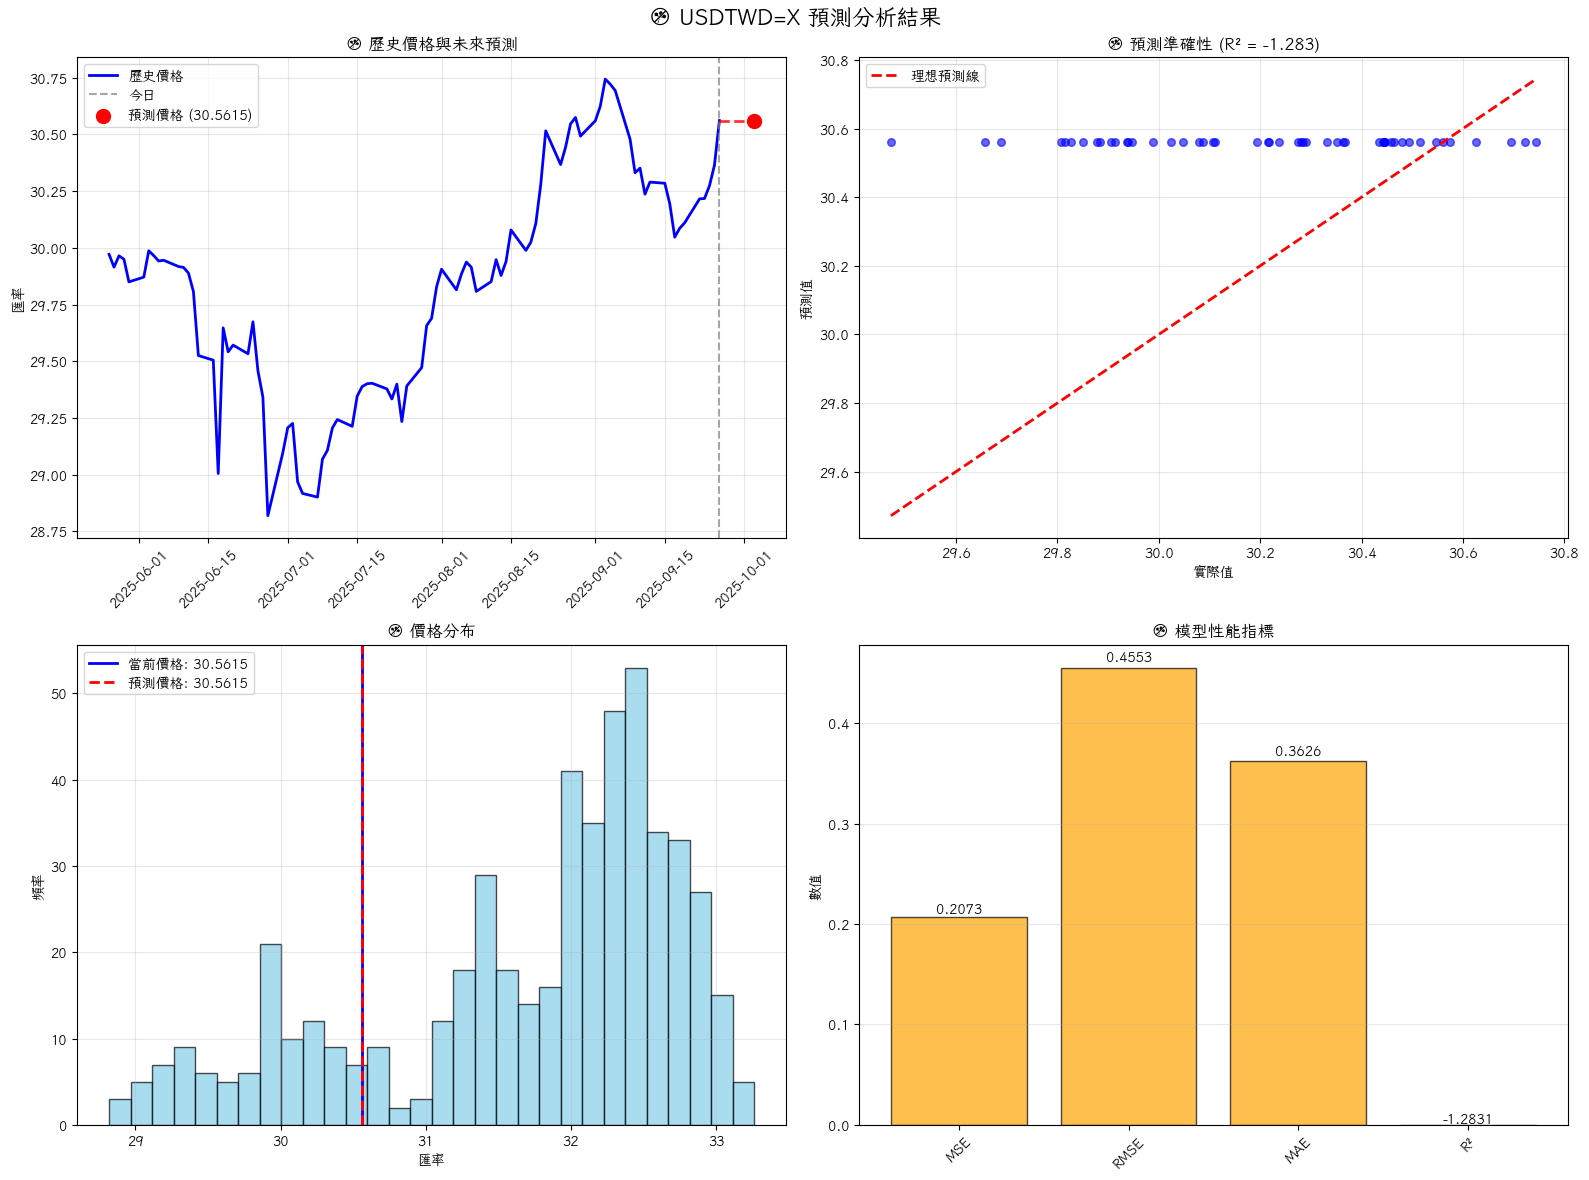

✅ 視覺化完成！
📊 使用特徵: ['Open', 'High', 'Low', 'Close', 'Volume']
📈 預測結果: 30.5615 → 30.5615 (+0.00%)


In [59]:
# 創建綜合視覺化圖表
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'💱 {main_pair} 預測分析結果', fontsize=16, fontweight='bold')

# 1. 歷史價格和預測
ax1 = axes[0, 0]
recent_period = df_model['Close'].tail(90)  # 最近90天
ax1.plot(recent_period.index, recent_period.values, 'b-', linewidth=2, label='歷史價格')
ax1.axvline(x=recent_period.index[-1], color='gray', linestyle='--', alpha=0.7, label='今日')
ax1.scatter([future_date], [future_price], color='red', s=100, zorder=5, label=f'預測價格 ({future_price:.4f})')
ax1.plot([recent_period.index[-1], future_date], [current_price, future_price], 'r--', linewidth=2, alpha=0.8)
ax1.set_title('📈 歷史價格與未來預測')
ax1.set_ylabel('匯率')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# 2. 測試集預測 vs 實際
ax2 = axes[0, 1]

# 處理預測結果格式問題
print(f"🔍 Debug: test_predictions 類型: {type(test_predictions)}")
print(f"🔍 Debug: test_predictions 長度: {len(test_predictions) if hasattr(test_predictions, '__len__') else 'No length'}")

try:
    # 將預測結果轉換為 numpy array
    if isinstance(test_predictions, list):
        # 如果是 list，嘗試提取數值
        pred_array = []
        for pred in test_predictions:
            if isinstance(pred, (list, np.ndarray)) and len(pred) > 0:
                pred_array.append(pred[-1])  # 取最後一個值
            elif isinstance(pred, (int, float)):
                pred_array.append(pred)
            else:
                pred_array.append(float(pred))  # 嘗試轉換為 float
        predictions_clean = np.array(pred_array)
    else:
        predictions_clean = np.array(test_predictions)
    
    # 確保長度匹配
    if len(predictions_clean) != len(y_test):
        if len(predictions_clean) == 1:
            predictions_clean = np.full(len(y_test), predictions_clean[0])
        else:
            min_len = min(len(predictions_clean), len(y_test))
            predictions_clean = predictions_clean[:min_len]
            y_test_plot = y_test.iloc[:min_len]
    else:
        y_test_plot = y_test
    
    print(f"🔍 Debug: 處理後 predictions_clean 形狀: {predictions_clean.shape}")
    print(f"🔍 Debug: y_test_plot 形狀: {y_test_plot.shape}")
    
    if len(predictions_clean) > 0 and len(y_test_plot) > 0:
        scatter_sample = min(50, len(y_test_plot))  # 減少點數避免過度擁擠
        if scatter_sample > 1:
            sample_indices = np.linspace(0, len(y_test_plot)-1, scatter_sample, dtype=int)
        else:
            sample_indices = [0]
        
        y_sample = y_test_plot.iloc[sample_indices]
        pred_sample = predictions_clean[sample_indices]
        
        ax2.scatter(y_sample, pred_sample, alpha=0.6, s=30, color='blue')
        
        min_val = min(y_test_plot.min(), predictions_clean.min())
        max_val = max(y_test_plot.max(), predictions_clean.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='理想預測線')
        ax2.set_xlabel('實際值')
        ax2.set_ylabel('預測值')
        ax2.set_title(f'🎯 預測準確性 (R² = {evaluation_results.get("R²", 0):.3f})')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, '預測資料處理失敗', ha='center', va='center', transform=ax2.transAxes, fontsize=14)
        ax2.set_title('🎯 預測準確性')

except Exception as e:
    print(f"⚠️ 散點圖處理錯誤: {e}")
    ax2.text(0.5, 0.5, f'預測資料格式錯誤\n{str(e)[:50]}...', ha='center', va='center', 
             transform=ax2.transAxes, fontsize=12, wrap=True)
    ax2.set_title('🎯 預測準確性 (處理錯誤)')

# 3. 價格分布
ax3 = axes[1, 0]
ax3.hist(df_model['Close'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax3.axvline(x=current_price, color='blue', linestyle='-', linewidth=2, label=f'當前價格: {current_price:.4f}')
ax3.axvline(x=future_price, color='red', linestyle='--', linewidth=2, label=f'預測價格: {future_price:.4f}')
ax3.set_xlabel('匯率')
ax3.set_ylabel('頻率')
ax3.set_title('📊 價格分布')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 模型性能指標
ax4 = axes[1, 1]
if evaluation_results:
    metrics = list(evaluation_results.keys())
    values = list(evaluation_results.values())

    # 標準化指標值以便比較
    normalized_values = []
    for i, (metric, value) in enumerate(evaluation_results.items()):
        if metric == 'R²':
            normalized_values.append(max(0, value))  # R²可以是負數，但圖表中顯示為0
        else:
            normalized_values.append(abs(value))  # 使用絕對值避免負數顯示問題

    colors = ['green' if metric == 'R²' else 'orange' for metric in metrics]
    bars = ax4.bar(metrics, normalized_values, color=colors, alpha=0.7, edgecolor='black')

    # 在柱狀圖上顯示數值
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                 f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

    ax4.set_title('📋 模型性能指標')
    ax4.set_ylabel('數值')
    ax4.grid(True, alpha=0.3, axis='y')
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)
else:
    ax4.text(0.5, 0.5, '無評估結果', ha='center', va='center', transform=ax4.transAxes, fontsize=14)
    ax4.set_title('📋 模型性能指標')

plt.tight_layout()
plt.show()

print("✅ 視覺化完成！")
print(f"📊 使用特徵: {available_features}")
print(f"📈 預測結果: {current_price:.4f} → {future_price:.4f} ({price_change_pct:+.2f}%)")

## 📈 進階分析：預測信心區間

In [ ]:
# 計算預測的信心區間
print("📊 計算預測信心區間...")

# 基於歷史波動率計算信心區間
price_returns = df_model['Close'].pct_change().dropna()
volatility = price_returns.std() * np.sqrt(7)  # 7天波動率

# 95% 信心區間
confidence_level = 1.96  # 95% 信心區間的 z-score
lower_bound = future_price - (confidence_level * volatility * current_price)
upper_bound = future_price + (confidence_level * volatility * current_price)

print(f"\n🎯 一週後預測結果 ({future_date.strftime('%Y-%m-%d')}):")
print(f"  預測價格: {future_price:.4f}")
print(f"  95% 信心區間: {lower_bound:.4f} ~ {upper_bound:.4f}")
print(f"  歷史波動率: {volatility:.2%}")

# 繪製信心區間圖
plt.figure(figsize=(12, 6))

# 繪製最近30天的價格
recent_30days = df_model['Close'].tail(30)
plt.plot(recent_30days.index, recent_30days.values, 'b-', linewidth=2, label='歷史價格')

# 繪製預測點和信心區間
plt.scatter([future_date], [future_price], color='red', s=100, zorder=5, label='預測價格')
plt.fill_between([future_date, future_date], [lower_bound, lower_bound], [upper_bound, upper_bound], 
                color='red', alpha=0.3, width=timedelta(days=1), label='95% 信心區間')

# 連接當前價格到預測
plt.plot([recent_30days.index[-1], future_date], [current_price, future_price], 'r--', 
         linewidth=2, alpha=0.8, label='預測趨勢')

plt.axvline(x=recent_30days.index[-1], color='gray', linestyle=':', alpha=0.7, label='今日')

plt.title(f'💱 {main_pair} 未來一週預測 (含信心區間)', fontsize=14, fontweight='bold')
plt.xlabel('日期')
plt.ylabel('匯率')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 投資建議
print(f"\n💡 投資建議:")
if price_change_pct > 2:
    print(f"  📈 預期大幅上漲 ({price_change_pct:+.2f}%) - 考慮買入")
elif price_change_pct > 0.5:
    print(f"  📈 預期溫和上漲 ({price_change_pct:+.2f}%) - 謹慎樂觀")
elif price_change_pct < -2:
    print(f"  📉 預期大幅下跌 ({price_change_pct:+.2f}%) - 考慮賣出")
elif price_change_pct < -0.5:
    print(f"  📉 預期溫和下跌 ({price_change_pct:+.2f}%) - 保持觀望")
else:
    print(f"  ➡️ 預期橫盤整理 ({price_change_pct:+.2f}%) - 維持現狀")

print(f"\n⚠️  風險提醒:")
print(f"  • 此預測僅供參考，不構成投資建議")
print(f"  • 匯率受多種因素影響，實際結果可能偏離預測")
print(f"  • 建議結合其他分析方法和風險管理策略")

## 📋 總結報告

In [ ]:
# 生成總結報告
print("\n" + "="*60)
print("📋 貨幣預測分析總結報告")
print("="*60)

print(f"\n🎯 分析標的: {main_pair}")
print(f"📅 分析時間: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 資料範圍: {df_model.index[0]} ~ {df_model.index[-1]} ({len(df_model)} 筆資料)")

print(f"\n🤖 模型資訊:")
print(f"  模型類型: HuggingFace PatchTST Transformer")
print(f"  特徵數量: {len(available_features)}")
print(f"  使用特徵: {', '.join(available_features)}")
print(f"  預測週期: {target_days} 天")

print(f"\n📊 模型性能:")
for metric, value in evaluation_results.items():
    print(f"  {metric}: {value:.4f}")

print(f"\n🔮 預測結果:")
print(f"  當前匯率: {current_price:.4f} ({last_date.strftime('%Y-%m-%d')})")
print(f"  預測匯率: {future_price:.4f} ({future_date.strftime('%Y-%m-%d')})")
print(f"  預期變化: {price_change:+.4f} ({price_change_pct:+.2f}%)")
print(f"  信心區間: {lower_bound:.4f} ~ {upper_bound:.4f} (95%)")

print(f"\n📈 市場觀察:")
recent_volatility = price_returns.tail(30).std() * 100
print(f"  近30日平均波動: {recent_volatility:.2f}%")

recent_trend = (df_model['Close'].tail(30).iloc[-1] - df_model['Close'].tail(30).iloc[0]) / df_model['Close'].tail(30).iloc[0] * 100
print(f"  近30日趨勢: {recent_trend:+.2f}%")

print(f"\n⚠️  免責聲明:")
print(f"  本分析僅供學習和參考，不構成任何投資建議。")
print(f"  匯率預測具有高度不確定性，請謹慎投資。")

print("\n✅ 分析完成！")
print("="*60)